%% [markdown]
# 01 — Análisis Exploratorio de Datos (EDA)
## Proyecto VI · Clasificación · Austin Animal Center
**Objetivo:** Entender la estructura de los datos, detectar patrones
por clase y determinar qué features tienen poder discriminante
antes de pasar al modelado.
**Dataset:** `data/processed/animal_eda.csv`
### Índice
1. Carga y verificación de calidad
2. Distribución de la variable objetivo
3. Análisis univariante — AgeInDays
4. Análisis univariante — variables categóricas
5. Análisis bivariante — cada feature vs OutcomeClass
6. DaysInShelter por clase (solo EDA)
7. Estacionalidad por mes
8. Análisis de razas en riesgo
9. Análisis multivariante — correlaciones
10. Conclusiones y decisiones para el modelado

%% [markdown]
---
## 1. Carga y verificación de calidad

%%

In [1]:

import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.size"] = 11

PALETTE = {
    "Adoption":        "#2ecc71",
    "Transfer":        "#3498db",
    "Return to Owner": "#f39c12",
    "At Risk":         "#e74c3c",
}
CLASS_ORDER = ["Adoption", "Transfer", "Return to Owner", "At Risk"]

df = pl.read_csv("../data/processed/animal_eda.csv")
df_pd = df.to_pandas()

print(f"Shape: {df.shape}")
print(f"\nNulos por columna:")
print(df.null_count())
print(f"\nTipos:")
print(df.dtypes)

Shape: (111055, 15)

Nulos por columna:
shape: (1, 15)
┌──────────┬────────────┬───────┬───────┬───┬────────┬─────────────┬───────────────┬──────────────┐
│ AnimalID ┆ AnimalType ┆ Breed ┆ Color ┆ … ┆ Season ┆ IntakeMonth ┆ DaysInShelter ┆ OutcomeClass │
│ ---      ┆ ---        ┆ ---   ┆ ---   ┆   ┆ ---    ┆ ---         ┆ ---           ┆ ---          │
│ u32      ┆ u32        ┆ u32   ┆ u32   ┆   ┆ u32    ┆ u32         ┆ u32           ┆ u32          │
╞══════════╪════════════╪═══════╪═══════╪═══╪════════╪═════════════╪═══════════════╪══════════════╡
│ 0        ┆ 0          ┆ 0     ┆ 0     ┆ … ┆ 0      ┆ 0           ┆ 0             ┆ 0            │
└──────────┴────────────┴───────┴───────┴───┴────────┴─────────────┴───────────────┴──────────────┘

Tipos:
[String, String, String, String, String, String, String, Float64, String, String, String, String, Int64, Int64, String]


 %% [markdown]
 ---
 ## 2. Distribucion de la variable objetivo

 Primer analisis siempre: cuantos registros hay por clase.
 Con desbalance esto condiciona toda la estrategia de modelado.

 %%

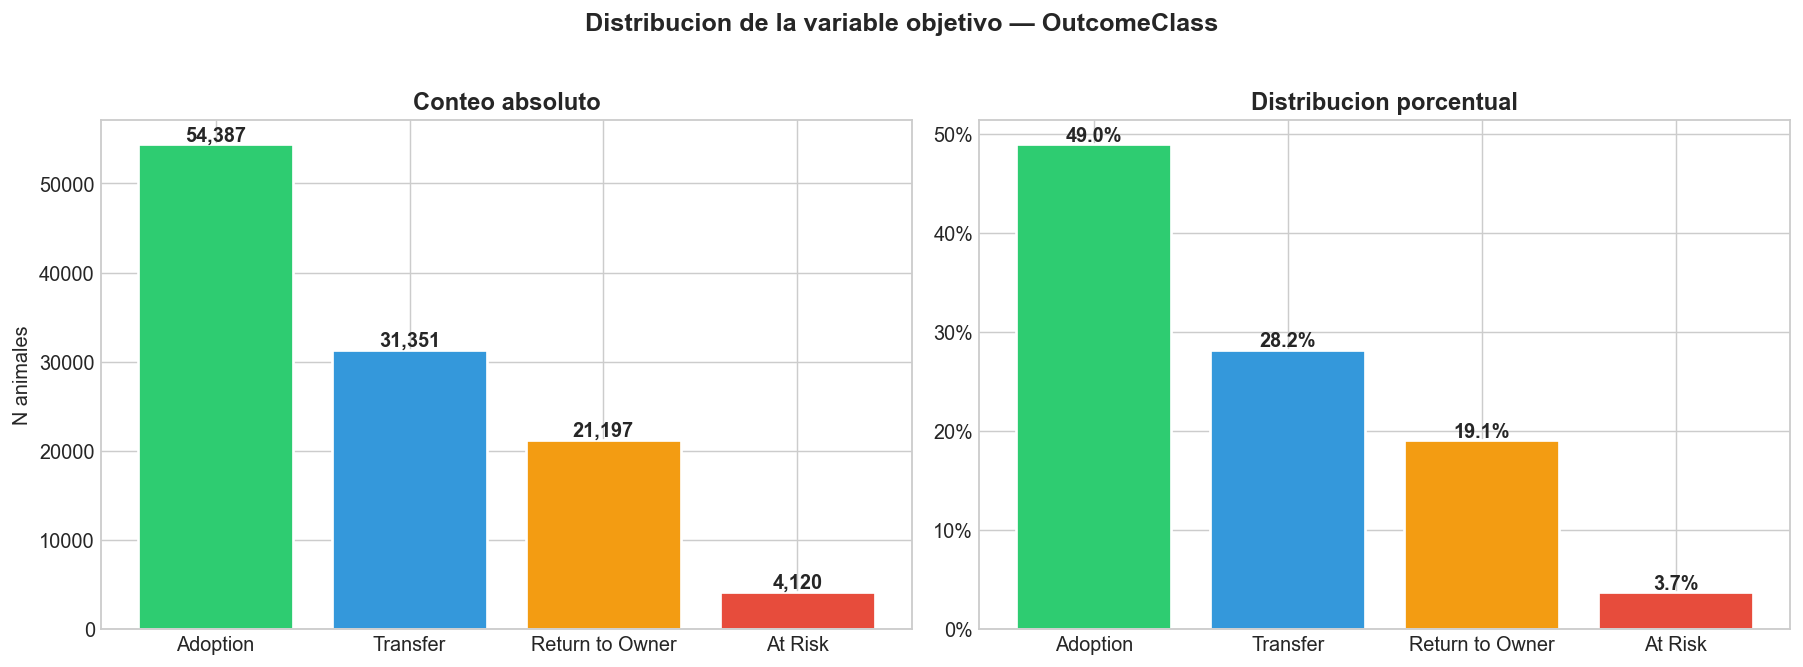


RESUMEN DESBALANCE:
  Adoption               54,387  (49.0%)  ████████████████████████
  Transfer               31,351  (28.2%)  ██████████████
  Return to Owner        21,197  (19.1%)  █████████
  At Risk                 4,120  ( 3.7%)  █

 At Risk es 3.7% del total
   Ratio mayor/menor clase: 13.2x


In [2]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribucion de la variable objetivo — OutcomeClass",
             fontsize=14, fontweight="bold", y=1.02)

counts = df["OutcomeClass"].value_counts().sort("count", descending=True)
labels = counts["OutcomeClass"].to_list()
values = counts["count"].to_list()
colors = [PALETTE[l] for l in labels]
total  = sum(values)

bars = axes[0].bar(labels, values, color=colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("Conteo absoluto", fontweight="bold")
axes[0].set_ylabel("N animales")
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 400,
                 f"{v:,}", ha="center", fontsize=11, fontweight="bold")

pcts  = [v/total*100 for v in values]
bars2 = axes[1].bar(labels, pcts, color=colors, edgecolor="white", linewidth=1.5)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Distribucion porcentual", fontweight="bold")
for bar, p in zip(bars2, pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{p:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRESUMEN DESBALANCE:")
for clase, n, pct in zip(labels, values, pcts):
    bar_str = chr(9608) * int(pct / 2)
    print(f"  {clase:<22} {n:>6,}  ({pct:4.1f}%)  {bar_str}")
print(f"\n At Risk es {pcts[-1]:.1f}% del total")
print(f"   Ratio mayor/menor clase: {max(values)/min(values):.1f}x")

 %% [markdown]
 ---
 ## 3. Analisis univariante — AgeInDays

 Unica variable numerica continua.
 Analizamos distribucion y outliers para decidir el escalador.
 %%

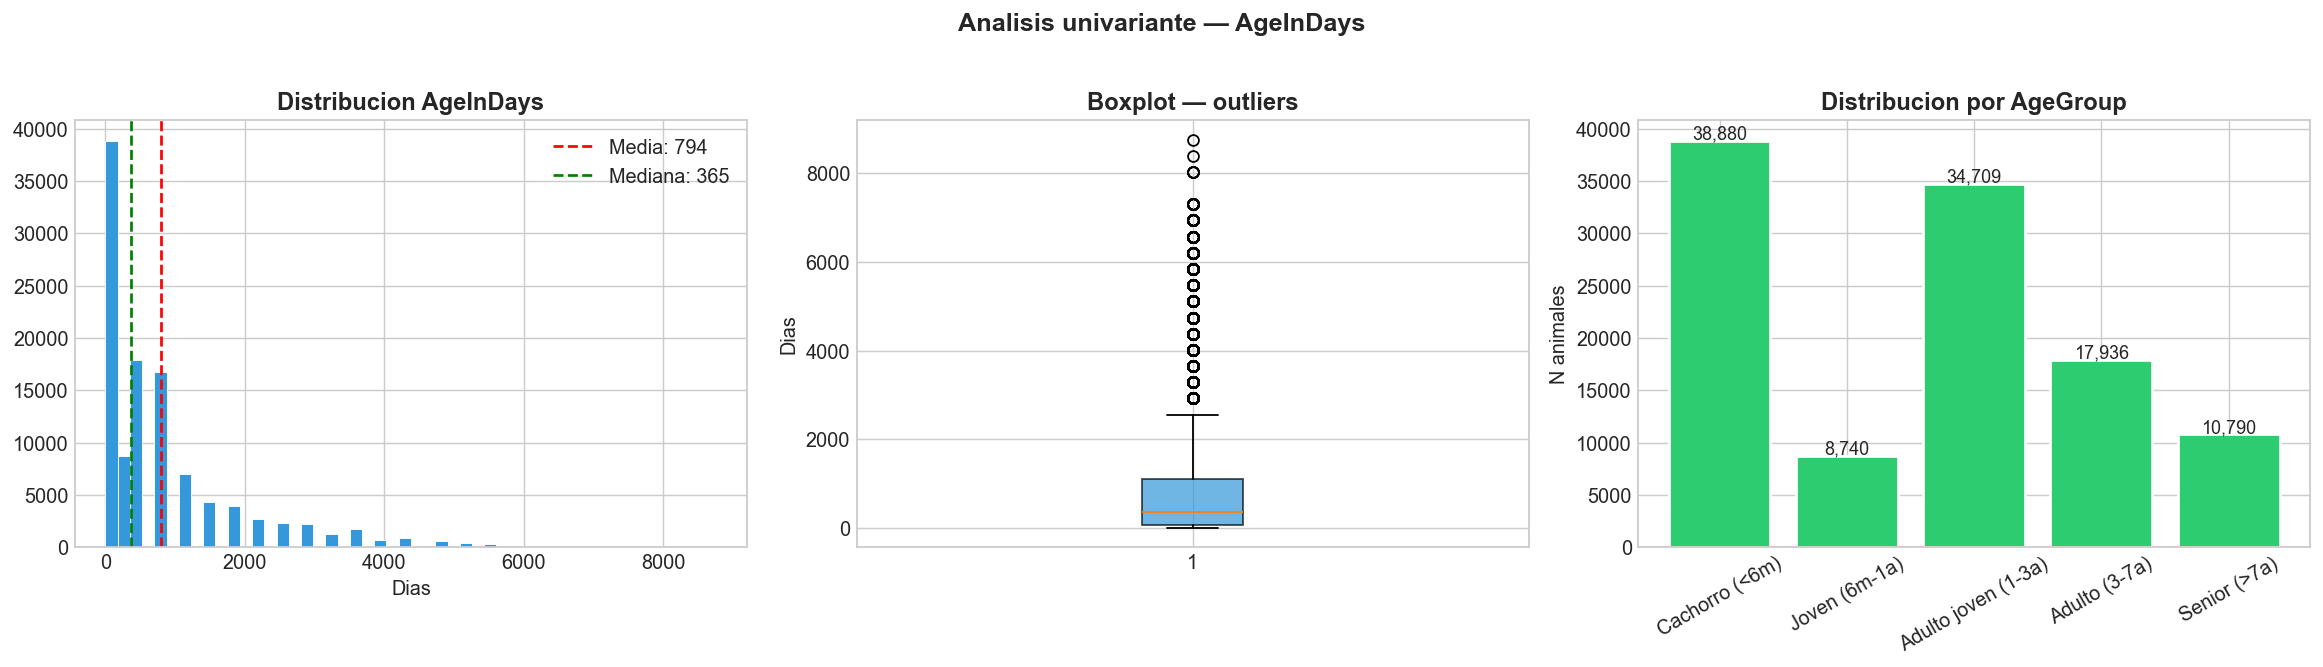

Skewness:  2.158
Media:     794 dias
Mediana:   365 dias
P95:       3285 dias

 Skewness > 1 — considerar RobustScaler en lugar de StandardScaler


In [3]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Analisis univariante — AgeInDays", fontsize=14, fontweight="bold", y=1.02)

axes[0].hist(df_pd["AgeInDays"], bins=50, color="#3498db", edgecolor="white", linewidth=0.5)
axes[0].axvline(df_pd["AgeInDays"].mean(),   color="red",   linestyle="--",
                label=f"Media: {df_pd['AgeInDays'].mean():.0f}")
axes[0].axvline(df_pd["AgeInDays"].median(), color="green", linestyle="--",
                label=f"Mediana: {df_pd['AgeInDays'].median():.0f}")
axes[0].set_title("Distribucion AgeInDays", fontweight="bold")
axes[0].set_xlabel("Dias")
axes[0].legend()

axes[1].boxplot(df_pd["AgeInDays"], patch_artist=True,
                boxprops=dict(facecolor="#3498db", alpha=0.7))
axes[1].set_title("Boxplot — outliers", fontweight="bold")
axes[1].set_ylabel("Dias")

age_order = ["Cachorro (<6m)", "Joven (6m-1a)", "Adulto joven (1-3a)",
             "Adulto (3-7a)", "Senior (>7a)"]
age_counts = df_pd["AgeGroup"].value_counts().reindex(age_order)
axes[2].bar(age_counts.index, age_counts.values,
            color="#2ecc71", edgecolor="white", linewidth=1.5)
axes[2].set_title("Distribucion por AgeGroup", fontweight="bold")
axes[2].tick_params(axis="x", rotation=30)
axes[2].set_ylabel("N animales")
for i, v in enumerate(age_counts.values):
    axes[2].text(i, v + 200, f"{v:,}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/figures/02_age_univariate.png", dpi=150, bbox_inches="tight")
plt.show()

skewness = df_pd["AgeInDays"].skew()
print(f"Skewness:  {skewness:.3f}")
print(f"Media:     {df_pd['AgeInDays'].mean():.0f} dias")
print(f"Mediana:   {df_pd['AgeInDays'].median():.0f} dias")
print(f"P95:       {df_pd['AgeInDays'].quantile(0.95):.0f} dias")
if skewness > 1:
    print("\n Skewness > 1 — considerar RobustScaler en lugar de StandardScaler")

C:\Users\zulay\AppData\Local\Temp\ipykernel_9764\1378908028.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pd, x="OutcomeClass", y="AgeInDays",
C:\Users\zulay\AppData\Local\Temp\ipykernel_9764\1378908028.py:33: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\zulay\Desktop\FactoriaF5\Bootcamp\IA\projects\Project_6_team3_Classification\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


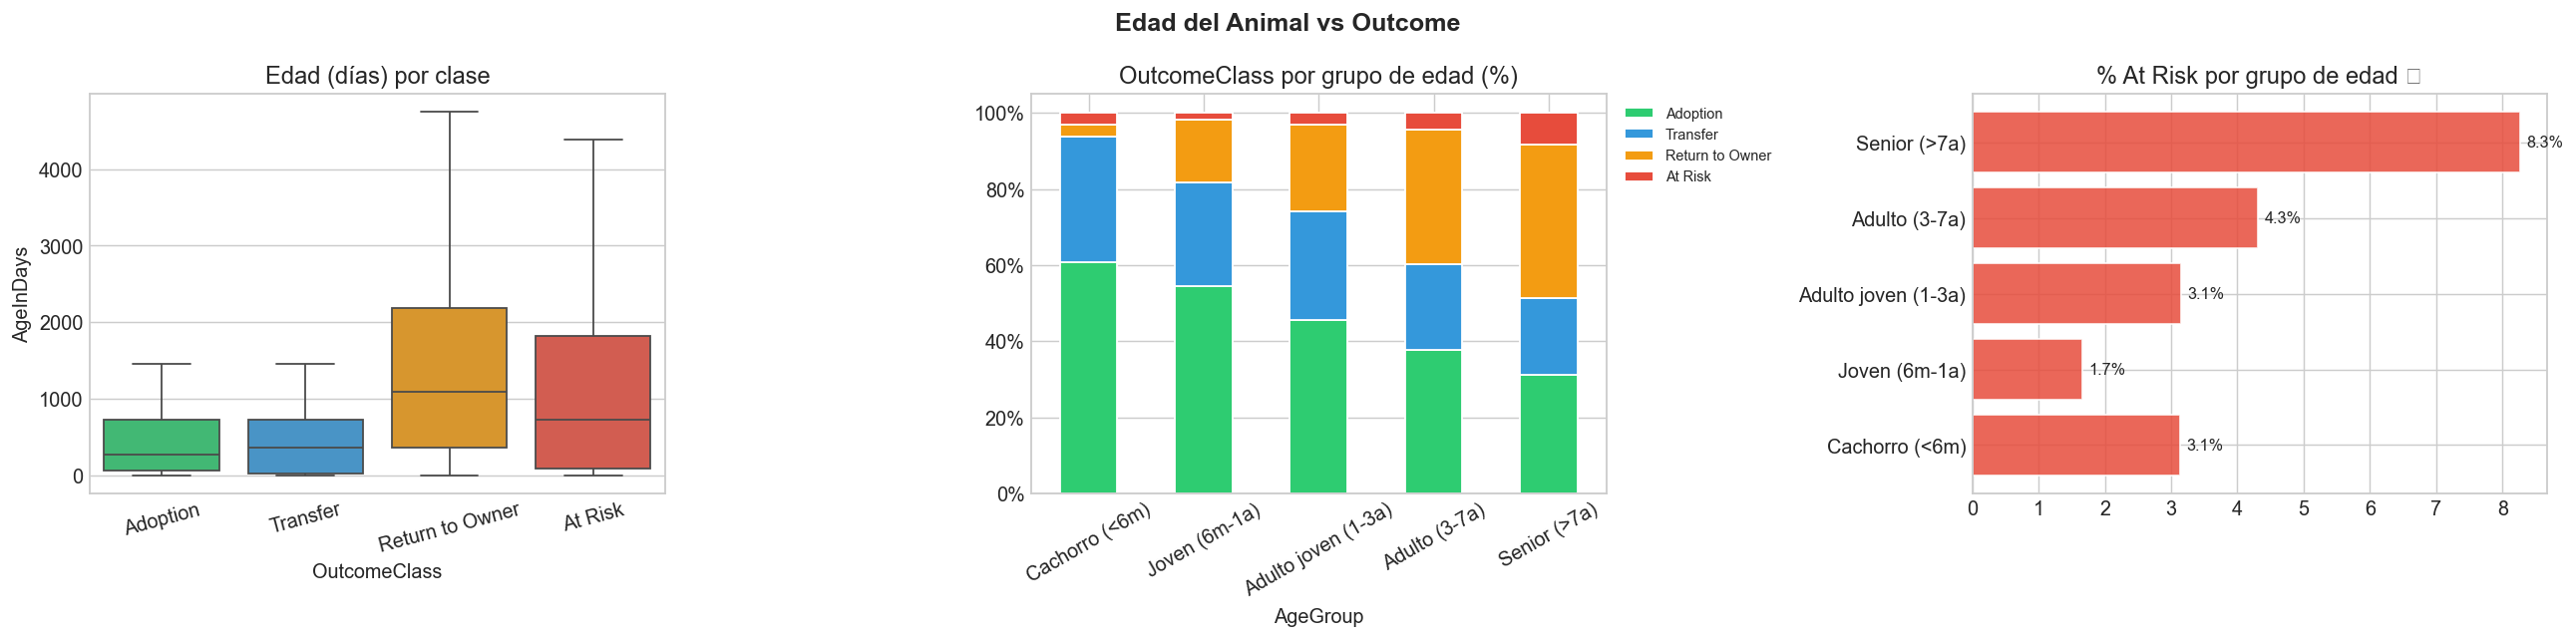

Estadísticas de edad por clase:


,median,mean,std
OutcomeClass,,,
Adoption,270.000000,592.000000,884.000000
Transfer,365.000000,644.000000,959.000000
Return to Owner,1095.000000,1431.000000,1312.000000
At Risk,730.000000,1313.000000,1556.000000


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Boxplot edad por clase
sns.boxplot(data=df_pd, x="OutcomeClass", y="AgeInDays",
            order=CLASS_ORDER, palette=PALETTE,
            ax=axes[0], showfliers=False)
axes[0].set_title("Edad (días) por clase")
axes[0].tick_params(axis="x", rotation=15)

# Stacked bar — AgeGroup vs OutcomeClass
age_order = ["Cachorro (<6m)", "Joven (6m-1a)", "Adulto joven (1-3a)",
             "Adulto (3-7a)", "Senior (>7a)"]
ct_ag = (pd.crosstab(df_pd["AgeGroup"], df_pd["OutcomeClass"])
           .reindex(index=age_order, columns=CLASS_ORDER, fill_value=0))
ct_ag_pct = ct_ag.div(ct_ag.sum(axis=1), axis=0) * 100
ct_ag_pct.plot(kind="bar", stacked=True, ax=axes[1],
               color=[PALETTE[c] for c in CLASS_ORDER],
               edgecolor="white")
axes[1].set_title("OutcomeClass por grupo de edad (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

# % At Risk por grupo de edad
at_risk_age = ct_ag_pct["At Risk"].reindex(age_order)
axes[2].barh(at_risk_age.index.astype(str), at_risk_age.values,
             color="#e74c3c", edgecolor="white", alpha=0.85)
axes[2].set_title("% At Risk por grupo de edad 🔴")
for i, v in enumerate(at_risk_age.values):
    axes[2].text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9)

plt.suptitle("Edad del Animal vs Outcome", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Estadísticas de edad por clase:")
display(df_pd.groupby("OutcomeClass")["AgeInDays"]
              .agg(["median", "mean", "std"])
              .reindex(CLASS_ORDER)
              .round(0)
              .style.background_gradient(cmap="Reds", subset=["median"]))

 %% [markdown]
 ---
 ## 4. Analisis univariante — variables categoricas

 Frecuencia de cada categoria. Detectamos si hay categorias
 con muy pocos registros que habria que agrupar.
 %%

C:\Users\zulay\AppData\Local\Temp\ipykernel_9764\1378908028.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pd, x="OutcomeClass", y="AgeInDays",
C:\Users\zulay\AppData\Local\Temp\ipykernel_9764\1378908028.py:33: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\zulay\Desktop\FactoriaF5\Bootcamp\IA\projects\Project_6_team3_Classification\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


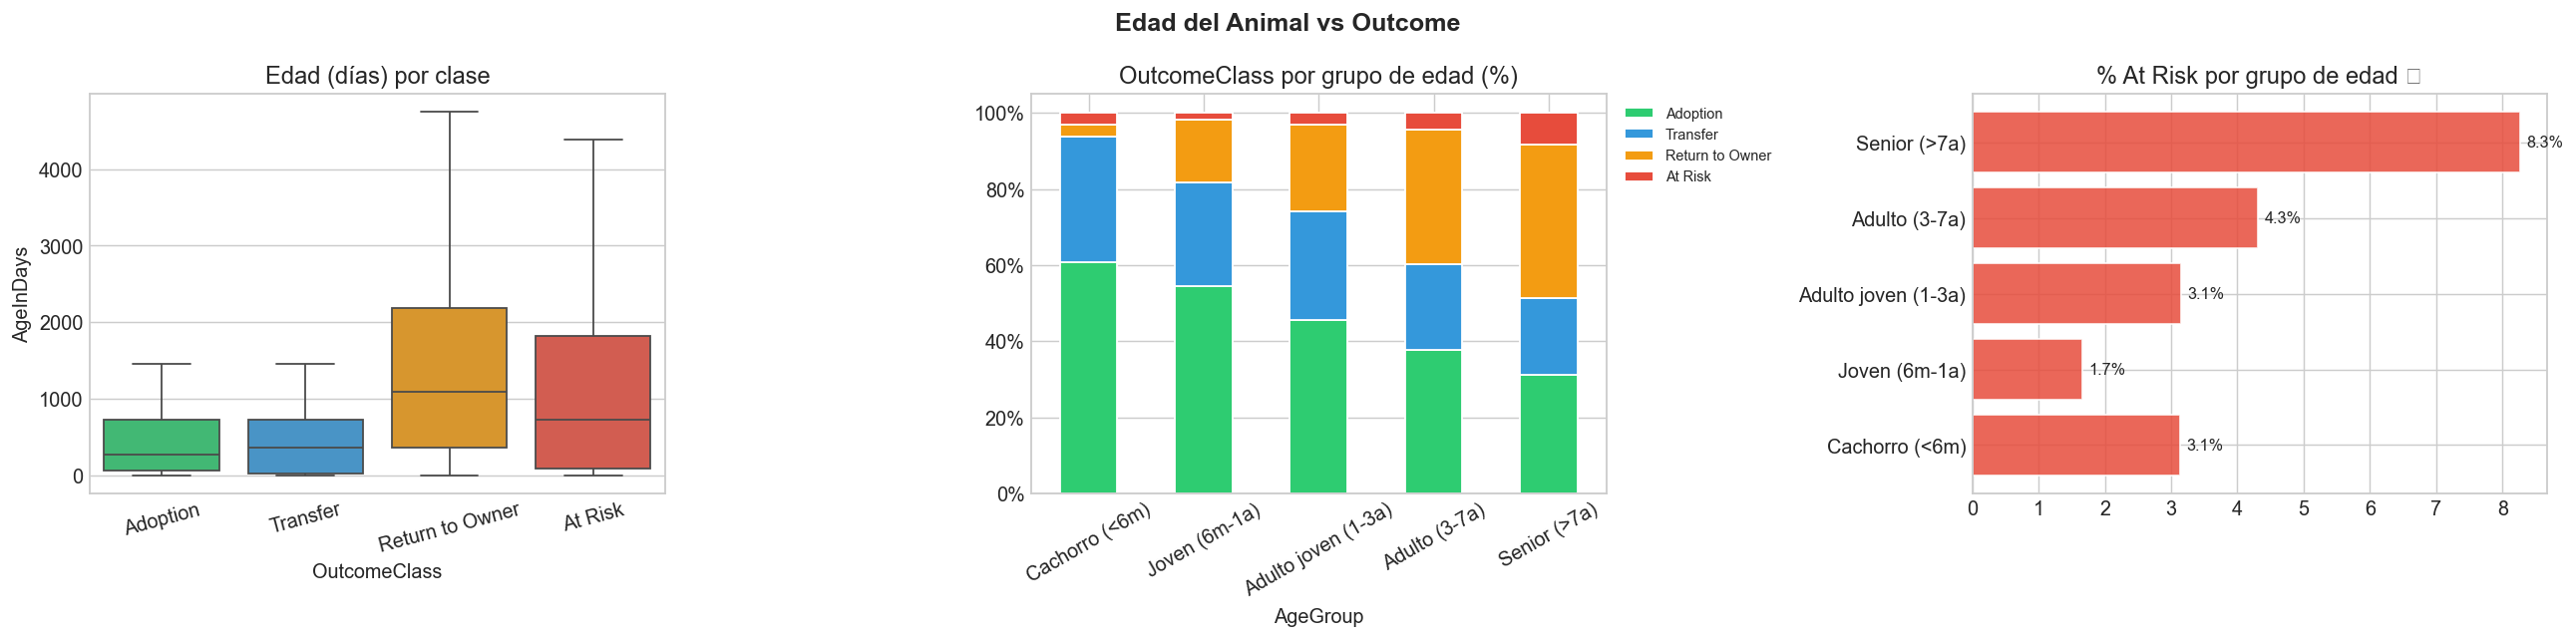

Estadísticas de edad por clase:


,median,mean,std
OutcomeClass,,,
Adoption,270.000000,592.000000,884.000000
Transfer,365.000000,644.000000,959.000000
Return to Owner,1095.000000,1431.000000,1312.000000
At Risk,730.000000,1313.000000,1556.000000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Boxplot edad por clase
sns.boxplot(data=df_pd, x="OutcomeClass", y="AgeInDays",
            order=CLASS_ORDER, palette=PALETTE,
            ax=axes[0], showfliers=False)
axes[0].set_title("Edad (días) por clase")
axes[0].tick_params(axis="x", rotation=15)

# Stacked bar — AgeGroup vs OutcomeClass
age_order = ["Cachorro (<6m)", "Joven (6m-1a)", "Adulto joven (1-3a)",
             "Adulto (3-7a)", "Senior (>7a)"]
ct_ag = (pd.crosstab(df_pd["AgeGroup"], df_pd["OutcomeClass"])
           .reindex(index=age_order, columns=CLASS_ORDER, fill_value=0))
ct_ag_pct = ct_ag.div(ct_ag.sum(axis=1), axis=0) * 100
ct_ag_pct.plot(kind="bar", stacked=True, ax=axes[1],
               color=[PALETTE[c] for c in CLASS_ORDER],
               edgecolor="white")
axes[1].set_title("OutcomeClass por grupo de edad (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

# % At Risk por grupo de edad
at_risk_age = ct_ag_pct["At Risk"].reindex(age_order)
axes[2].barh(at_risk_age.index.astype(str), at_risk_age.values,
             color="#e74c3c", edgecolor="white", alpha=0.85)
axes[2].set_title("% At Risk por grupo de edad 🔴")
for i, v in enumerate(at_risk_age.values):
    axes[2].text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=9)

plt.suptitle("Edad del Animal vs Outcome", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Estadísticas de edad por clase:")
display(df_pd.groupby("OutcomeClass")["AgeInDays"]
              .agg(["median", "mean", "std"])
              .reindex(CLASS_ORDER)
              .round(0)
              .style.background_gradient(cmap="Reds", subset=["median"]))

 %% [markdown]
 ---
 ## 5. Analisis bivariante — cada feature vs OutcomeClass

 Cruzamos cada feature con el target para ver si hay diferencias
 entre clases. Si no las hay, la feature no aportara al modelo.
 %%

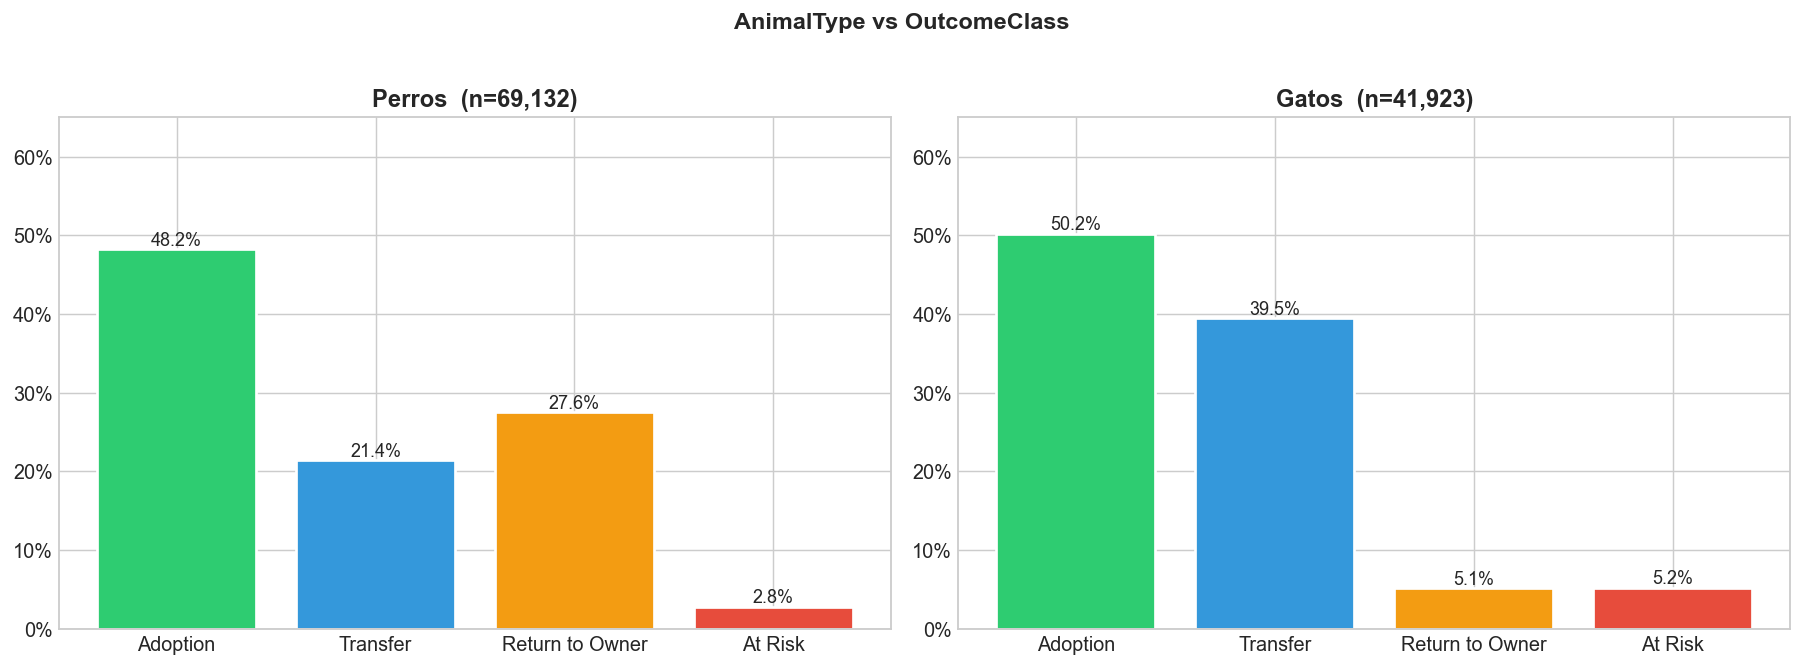

In [6]:

# 5.1 AnimalType vs OutcomeClass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("AnimalType vs OutcomeClass", fontsize=13, fontweight="bold", y=1.02)

for ax, animal in zip(axes, ["Dog", "Cat"]):
    sub = df_pd[df_pd["AnimalType"] == animal]
    ct  = sub["OutcomeClass"].value_counts().reindex(CLASS_ORDER).fillna(0)
    pct = ct / ct.sum() * 100
    bars = ax.bar(ct.index, pct.values,
                  color=[PALETTE[c] for c in ct.index],
                  edgecolor="white", linewidth=1.5)
    ax.set_title(f"{'Perros' if animal=='Dog' else 'Gatos'}  (n={len(sub):,})",
                 fontweight="bold")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 65)
    for bar, p in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f"{p:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/figures/04_animaltype_vs_class.png", dpi=150, bbox_inches="tight")
plt.show()

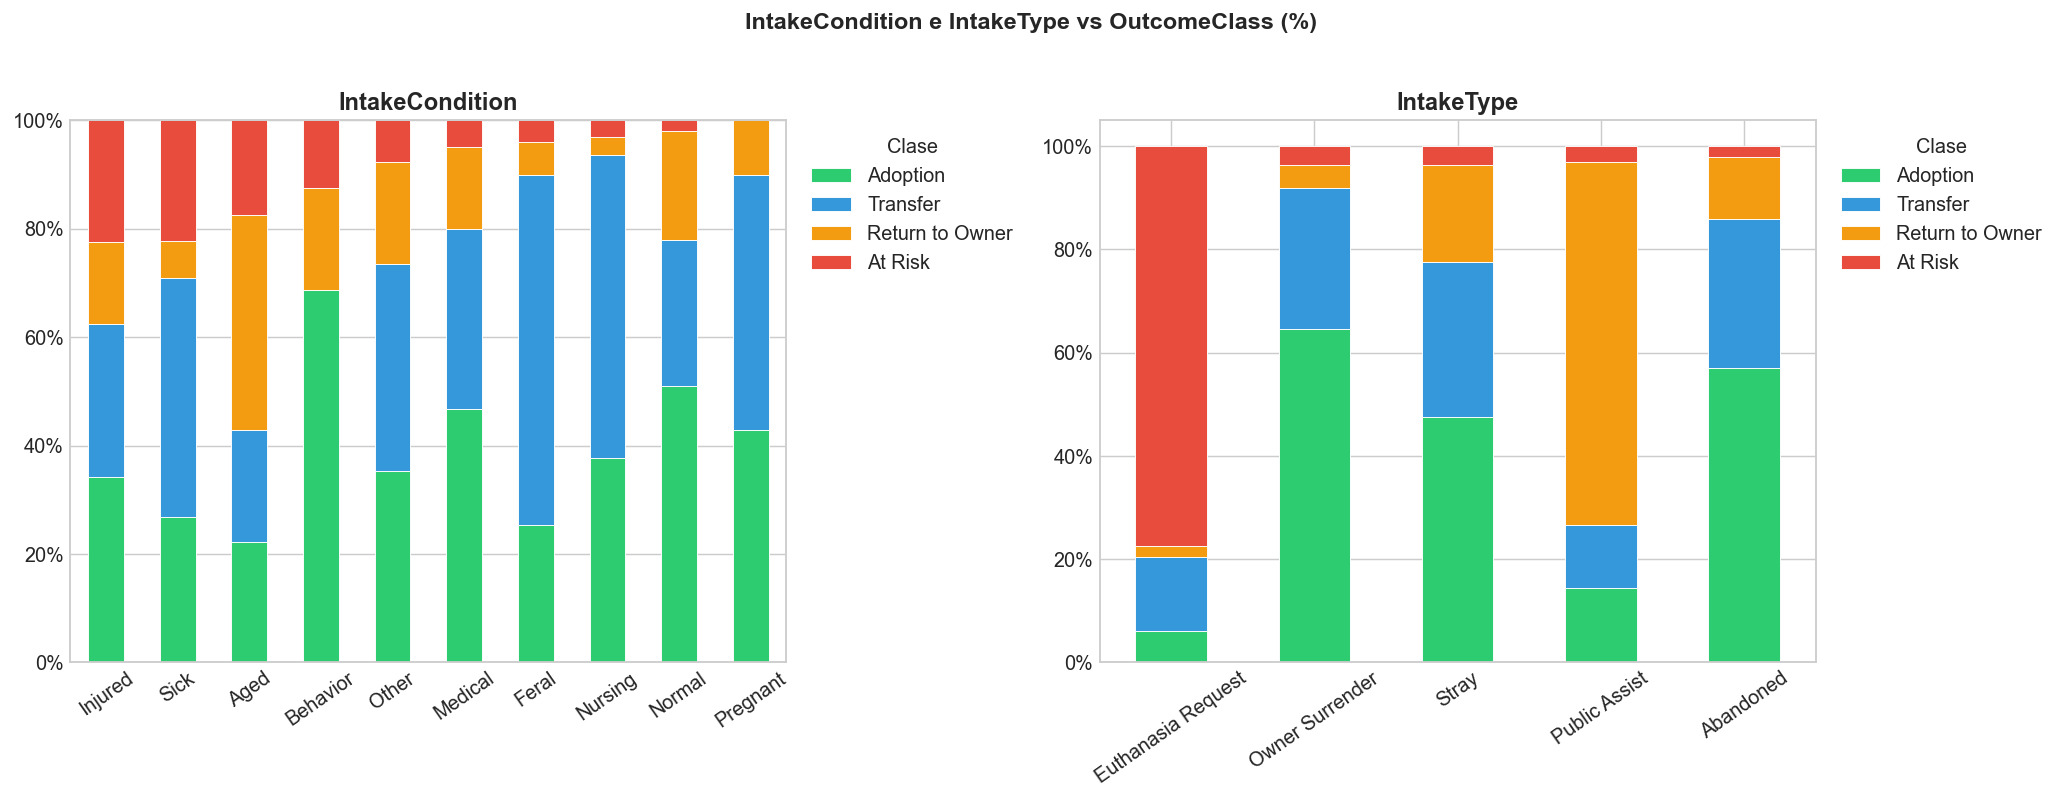

In [7]:
# %%
# 5.2 IntakeCondition e IntakeType vs OutcomeClass (stacked %)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("IntakeCondition e IntakeType vs OutcomeClass (%)",
             fontsize=13, fontweight="bold", y=1.02)

for ax, col in zip(axes, ["IntakeCondition", "IntakeType"]):
    ct2   = df_pd.groupby([col, "OutcomeClass"]).size().unstack(fill_value=0)
    ct2   = ct2.reindex(columns=CLASS_ORDER, fill_value=0)
    pct2  = ct2.div(ct2.sum(axis=1), axis=0) * 100
    pct2  = pct2.sort_values("At Risk", ascending=False)
    pct2.plot(kind="bar", stacked=True, ax=ax,
              color=[PALETTE[c] for c in CLASS_ORDER],
              edgecolor="white", linewidth=0.5)
    ax.set_title(col, fontweight="bold")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="Clase", bbox_to_anchor=(1.01, 1))
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("../reports/figures/05_intake_vs_class.png", dpi=150, bbox_inches="tight")
plt.show()

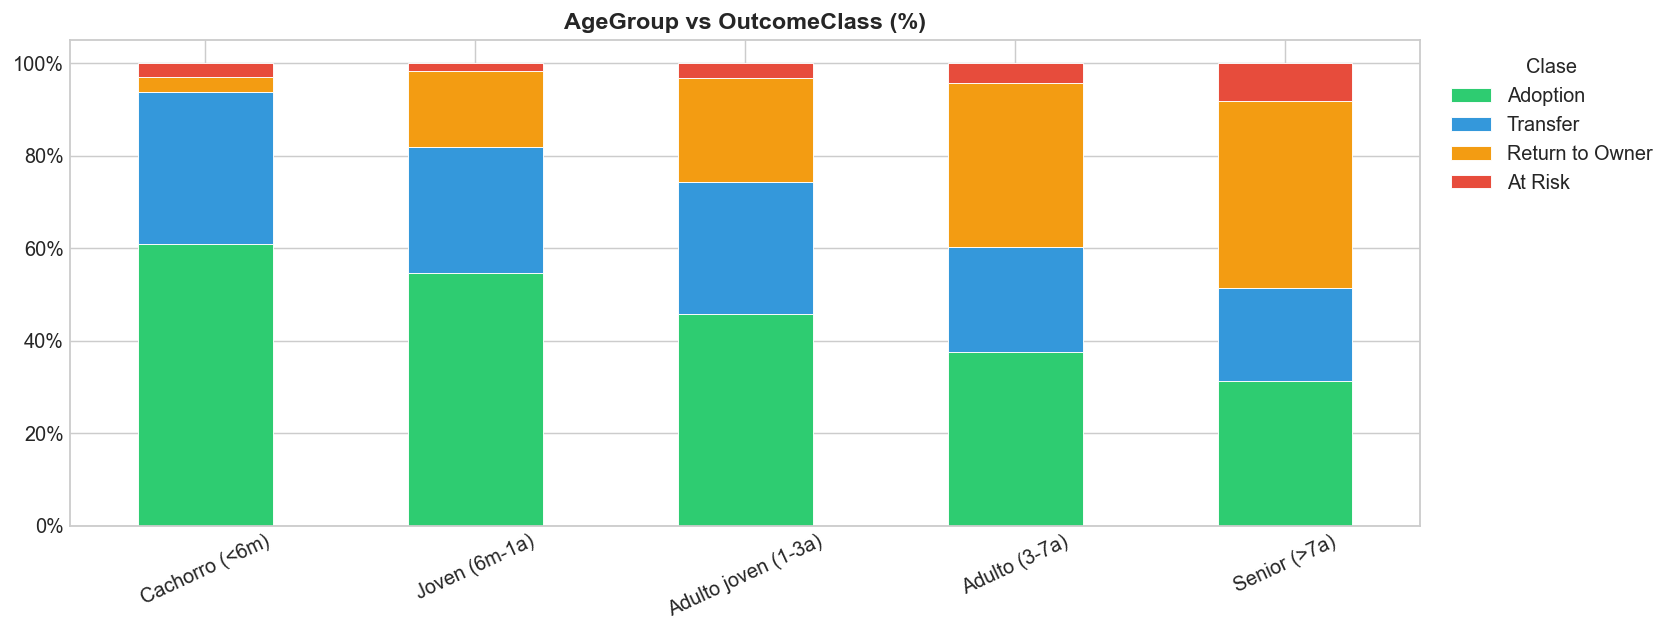

In [8]:
# %%
# 5.3 AgeGroup vs OutcomeClass
age_order = ["Cachorro (<6m)", "Joven (6m-1a)", "Adulto joven (1-3a)",
             "Adulto (3-7a)", "Senior (>7a)"]
ct3  = df_pd.groupby(["AgeGroup", "OutcomeClass"]).size().unstack(fill_value=0)
ct3  = ct3.reindex(index=age_order, columns=CLASS_ORDER, fill_value=0)
pct3 = ct3.div(ct3.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 5))
pct3.plot(kind="bar", stacked=True, ax=ax,
          color=[PALETTE[c] for c in CLASS_ORDER],
          edgecolor="white", linewidth=0.5)
ax.set_title("AgeGroup vs OutcomeClass (%)", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Clase", bbox_to_anchor=(1.01, 1))
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../reports/figures/06_agegroup_vs_class.png", dpi=150, bbox_inches="tight")
plt.show()

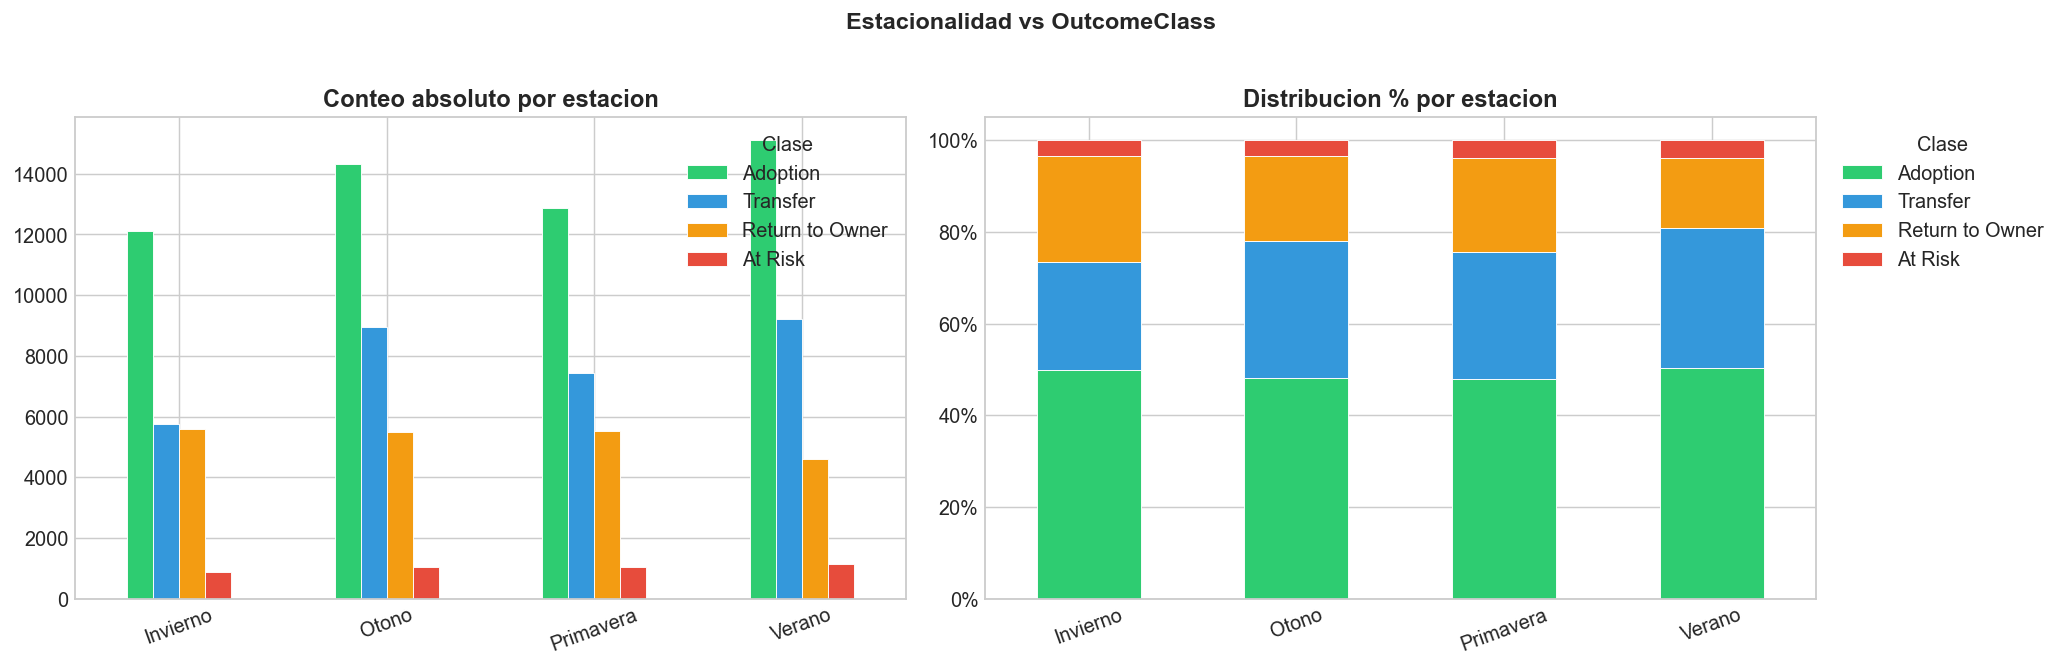

In [9]:
# %%
# 5.4 Season vs OutcomeClass
season_order = ["Primavera", "Verano", "Otono", "Invierno"]
df_pd["Season"] = df_pd["Season"].replace({"Otoño": "Otono"})

ct4  = df_pd.groupby(["Season", "OutcomeClass"]).size().unstack(fill_value=0)
ct4  = ct4.reindex(columns=CLASS_ORDER, fill_value=0)
pct4 = ct4.div(ct4.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Estacionalidad vs OutcomeClass", fontsize=13, fontweight="bold", y=1.02)

ct4.plot(kind="bar", ax=axes[0], color=[PALETTE[c] for c in CLASS_ORDER],
         edgecolor="white", linewidth=0.5)
axes[0].set_title("Conteo absoluto por estacion", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Clase")
axes[0].set_xlabel("")

pct4.plot(kind="bar", stacked=True, ax=axes[1],
          color=[PALETTE[c] for c in CLASS_ORDER],
          edgecolor="white", linewidth=0.5)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title("Distribucion % por estacion", fontweight="bold")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Clase", bbox_to_anchor=(1.01, 1))
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig("../reports/figures/07_season_vs_class.png", dpi=150, bbox_inches="tight")
plt.show()

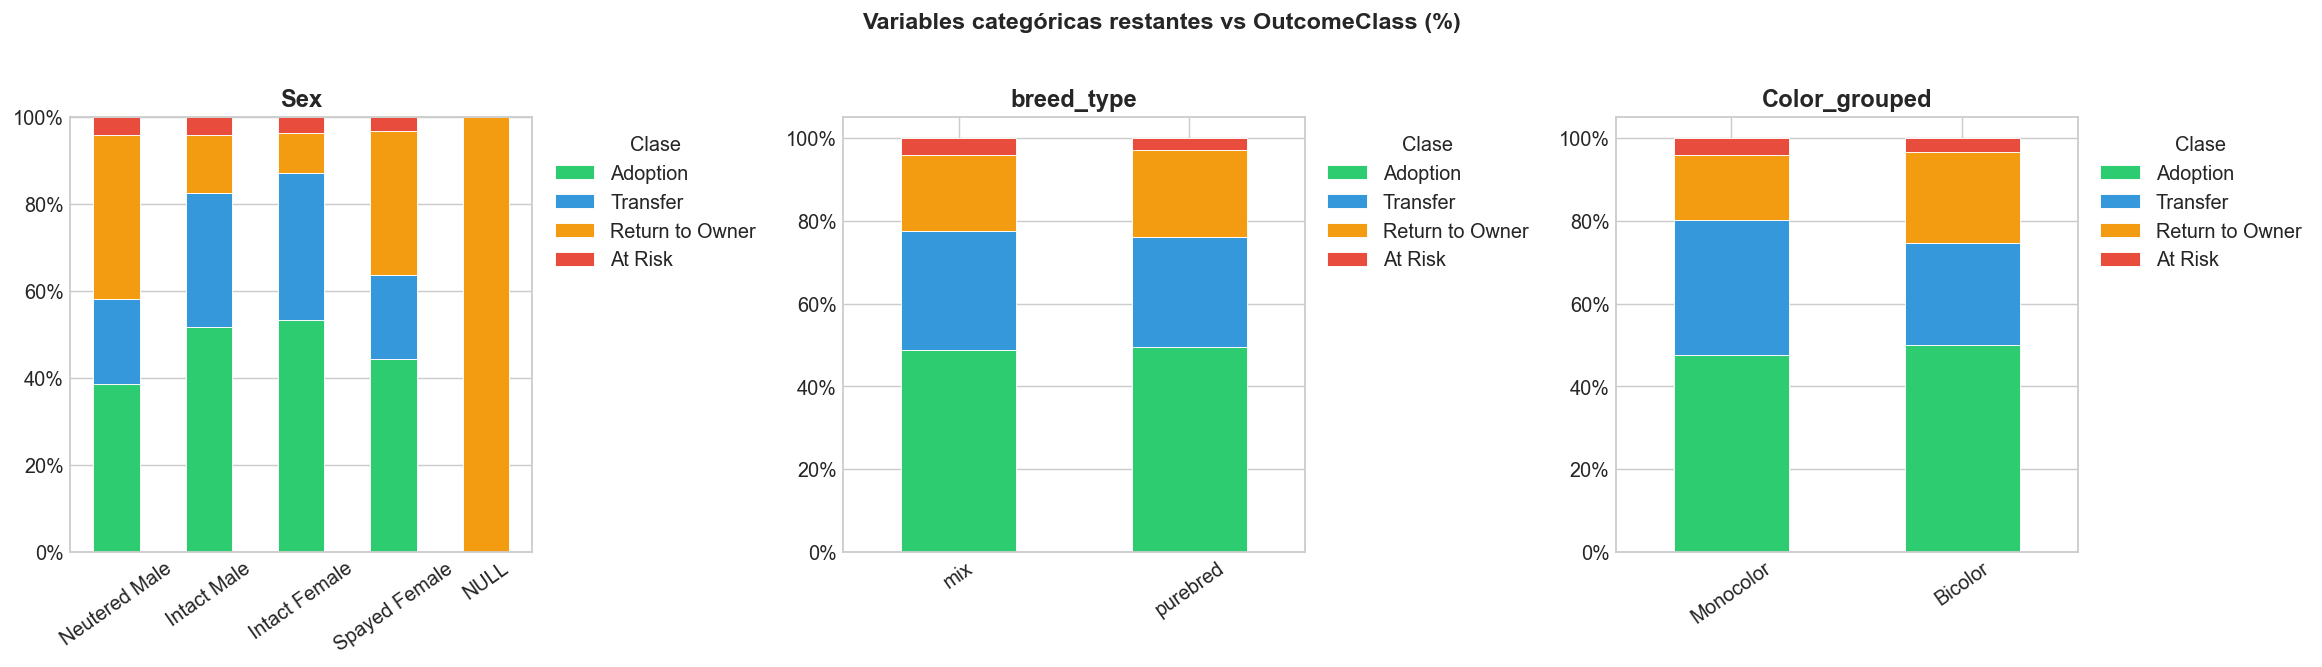

% At Risk por variable:

  Sex:
Sex
Intact Female    3.50
Intact Male      3.96
NULL             0.00
Neutered Male    4.09
Spayed Female    3.13

  breed_type:
breed_type
mix         3.98
purebred    2.95

  Color_grouped:
Color_grouped
Bicolor      3.33
Monocolor    4.17


In [10]:
# ── 5.5 Variables categóricas restantes vs OutcomeClass ──
remaining_cats = ["Sex", "breed_type", "Color_grouped"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Variables categóricas restantes vs OutcomeClass (%)",
             fontsize=13, fontweight="bold", y=1.02)

for ax, col in zip(axes, remaining_cats):
    ct = df_pd.groupby([col, "OutcomeClass"]).size().unstack(fill_value=0)
    ct = ct.reindex(columns=CLASS_ORDER, fill_value=0)
    pct = ct.div(ct.sum(axis=1), axis=0) * 100
    pct = pct.sort_values("At Risk", ascending=False)
    pct.plot(kind="bar", stacked=True, ax=ax,
             color=[PALETTE[c] for c in CLASS_ORDER],
             edgecolor="white", linewidth=0.5)
    ax.set_title(col, fontweight="bold")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="Clase", bbox_to_anchor=(1.01, 1))
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("../reports/figures/05b_remaining_cats_vs_class.png",
            dpi=150, bbox_inches="tight")
plt.show()

# % At Risk por cada categoría
print("% At Risk por variable:")
for col in remaining_cats:
    print(f"\n  {col}:")
    ct = df_pd.groupby(col)["OutcomeClass"].apply(
        lambda x: (x == "At Risk").mean() * 100
    ).round(2)
    print(ct.to_string())

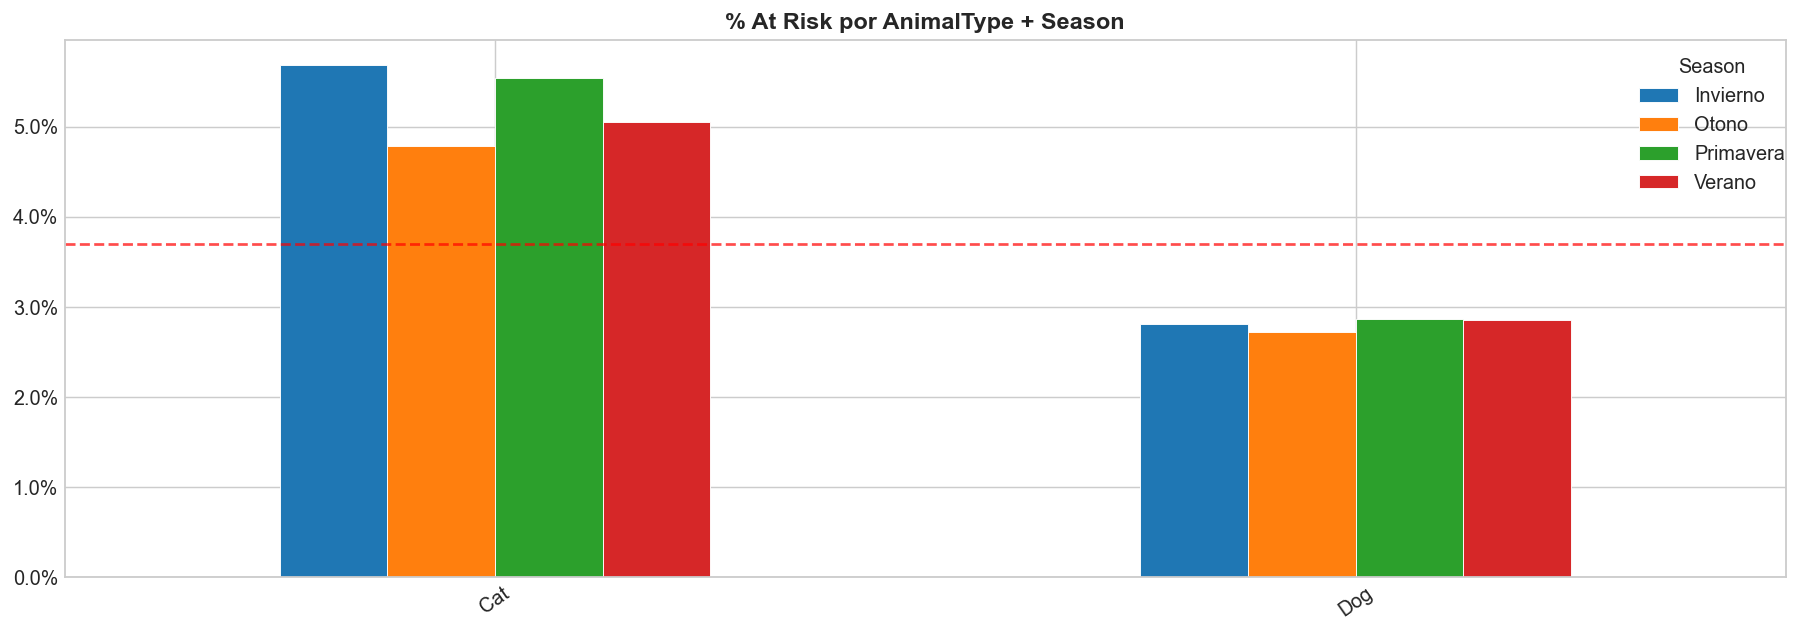


% At Risk — AnimalType + Season:
Season      Invierno  Otono  Primavera  Verano
AnimalType                                    
Cat             5.68   4.78       5.54    5.05
Dog             2.81   2.72       2.87    2.85


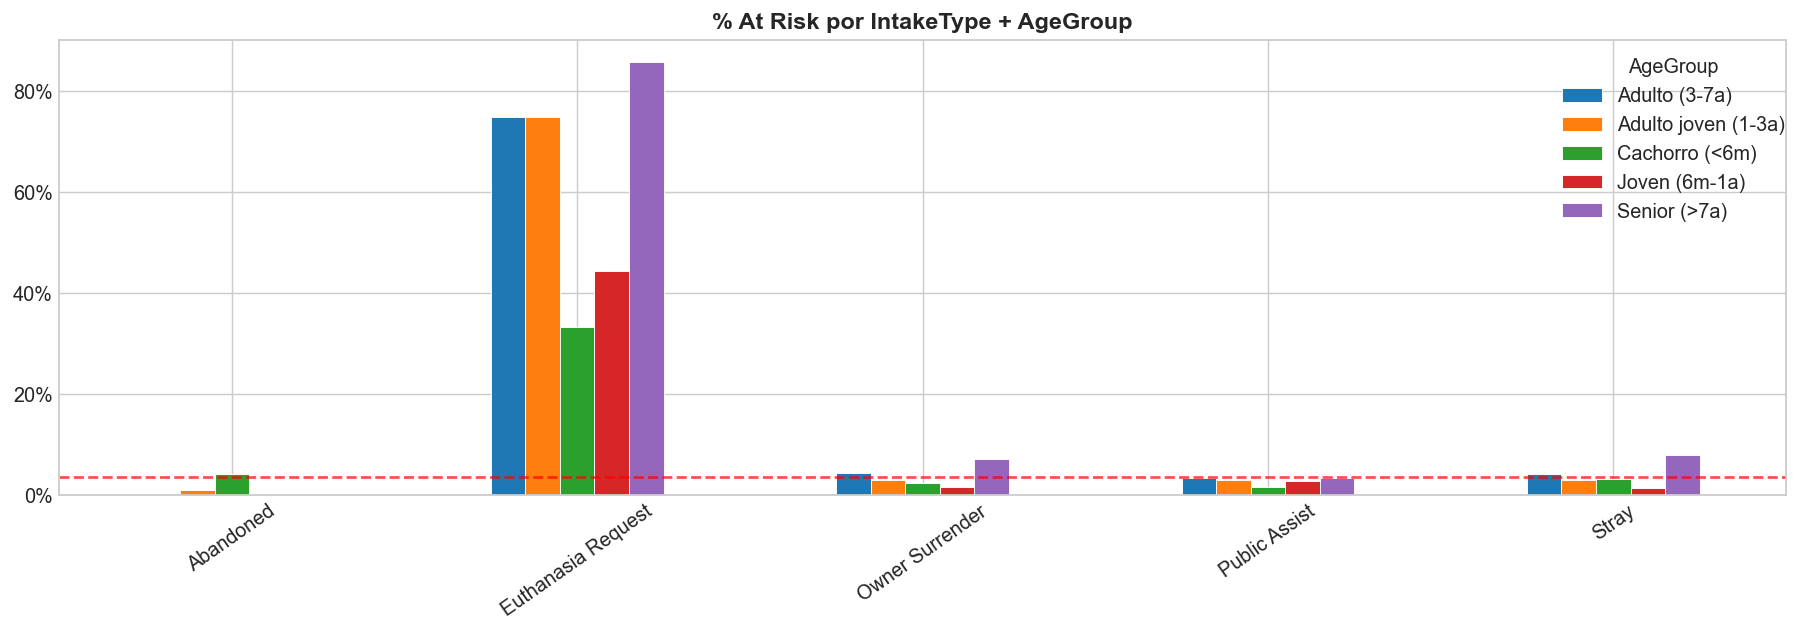


% At Risk — IntakeType + AgeGroup:
AgeGroup            Adulto (3-7a)  Adulto joven (1-3a)  Cachorro (<6m)  Joven (6m-1a)  Senior (>7a)
IntakeType                                                                                         
Abandoned                    0.00                 1.04            4.21           0.00          0.00
Euthanasia Request          75.00                75.00           33.33          44.44         85.93
Owner Surrender              4.46                 3.11            2.39           1.72          7.17
Public Assist                3.46                 2.96            1.74           2.77          3.43
Stray                        4.17                 3.09            3.29           1.50          8.03


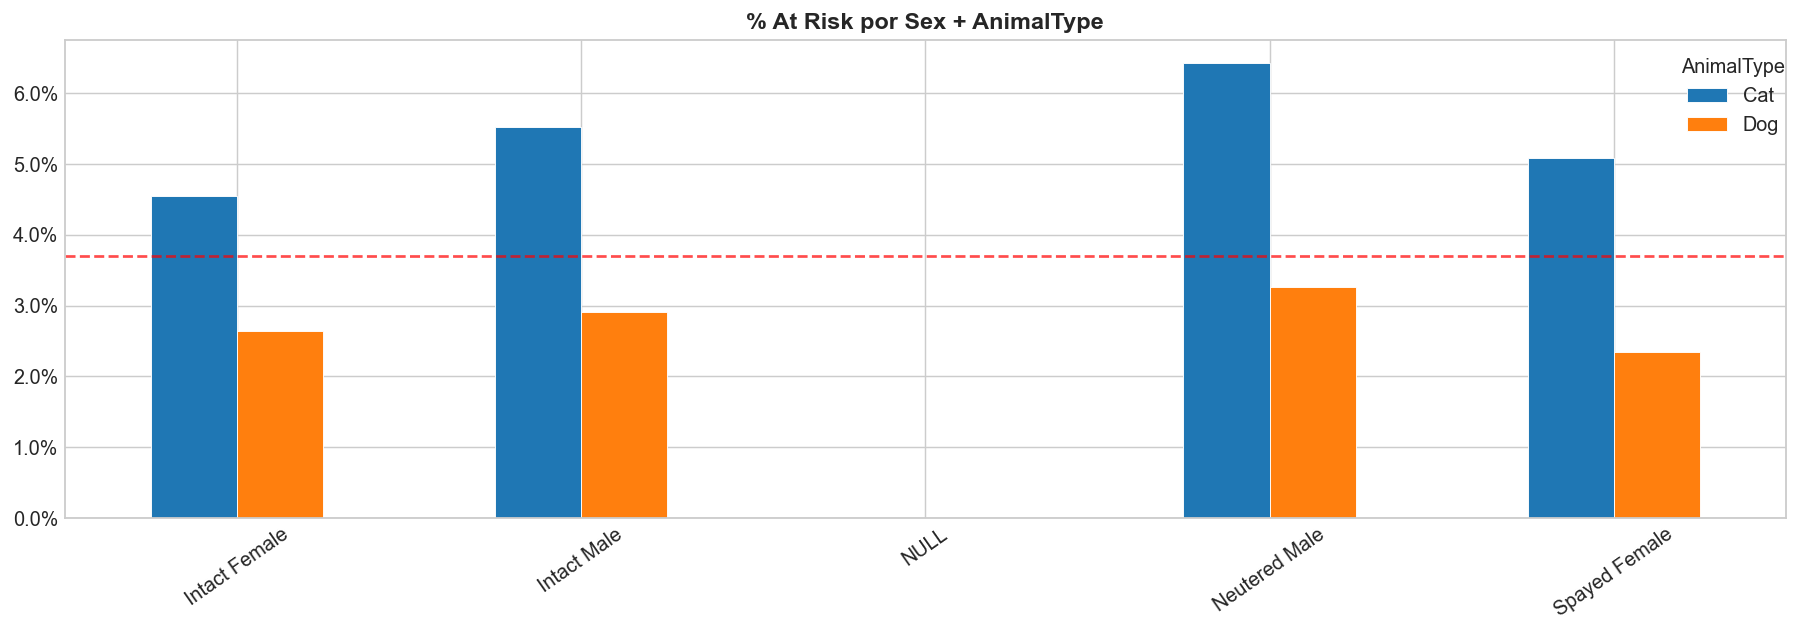


% At Risk — Sex + AnimalType:
AnimalType      Cat   Dog
Sex                      
Intact Female  4.55  2.65
Intact Male    5.52  2.91
NULL            NaN  0.00
Neutered Male  6.43  3.26
Spayed Female  5.08  2.35


In [11]:
# ── 5.6 Multivariante — combinaciones de dos categóricas ──
combos = [
    ("AnimalType", "Season"),
    ("IntakeType",  "AgeGroup"),
    ("Sex",         "AnimalType"),
]

for col1, col2 in combos:
    ct = df_pd.groupby([col1, col2, "OutcomeClass"]).size().unstack(fill_value=0)
    ct = ct.reindex(columns=CLASS_ORDER, fill_value=0)
    pct = ct.div(ct.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(14, 5))
    pct["At Risk"].unstack().plot(kind="bar", ax=ax,
                                   edgecolor="white", linewidth=0.5)
    ax.set_title(f"% At Risk por {col1} + {col2}",
                 fontsize=13, fontweight="bold")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title=col2, bbox_to_anchor=(1.01, 1))
    ax.set_xlabel("")
    ax.axhline(3.7, color="red", linestyle="--", alpha=0.7,
               label="Media global 3.7%")
    plt.tight_layout()
    plt.savefig(f"../reports/figures/multiv_{col1}_{col2}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\n% At Risk — {col1} + {col2}:")
    print(pct["At Risk"].unstack().round(2).to_string())

 %% [markdown]
 ---
 ## 6. DaysInShelter por clase

 SOLO EDA — no entra al modelo (data leakage).
 Confirma si animales At Risk pasan mas tiempo en el refugio.
 %%

C:\Users\zulay\AppData\Local\Temp\ipykernel_9764\3218645557.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pd, x="OutcomeClass", y="DaysInShelter",


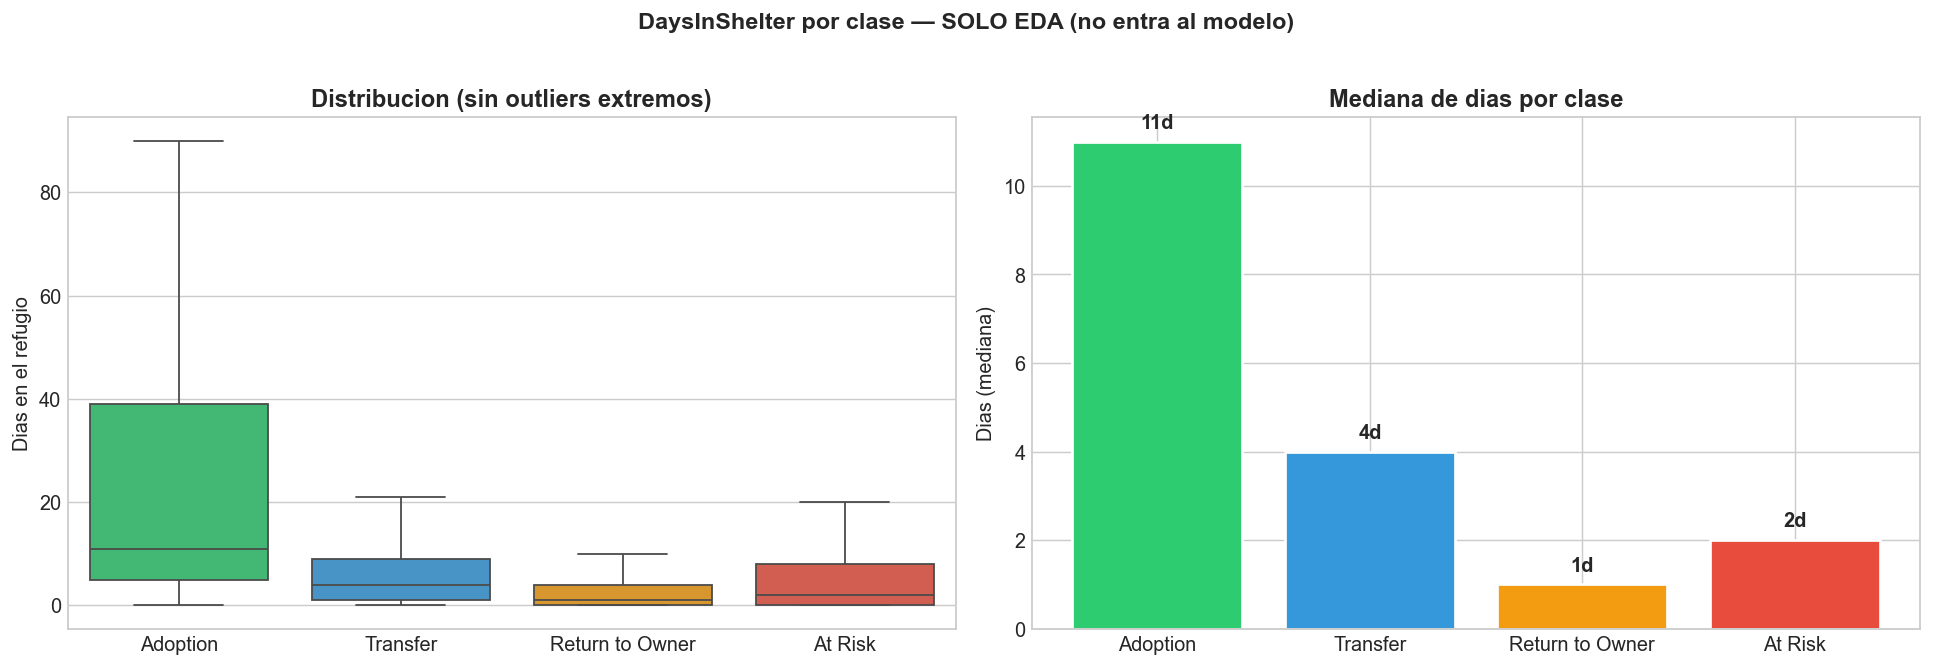

Estadisticos DaysInShelter por clase:
                 median  mean   std
OutcomeClass                       
Adoption           11.0  31.9  57.5
Transfer            4.0   9.9  22.8
Return to Owner     1.0   3.1   6.9
At Risk             2.0  12.4  45.5


In [12]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("DaysInShelter por clase — SOLO EDA (no entra al modelo)",
             fontsize=13, fontweight="bold", y=1.02)

sns.boxplot(data=df_pd, x="OutcomeClass", y="DaysInShelter",
            order=CLASS_ORDER, palette=PALETTE, ax=axes[0], showfliers=False)
axes[0].set_title("Distribucion (sin outliers extremos)", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Dias en el refugio")

medians = df_pd.groupby("OutcomeClass")["DaysInShelter"].median().reindex(CLASS_ORDER)
bars = axes[1].bar(medians.index, medians.values,
                   color=[PALETTE[c] for c in medians.index],
                   edgecolor="white", linewidth=1.5)
axes[1].set_title("Mediana de dias por clase", fontweight="bold")
axes[1].set_ylabel("Dias (mediana)")
for bar, v in zip(bars, medians.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{v:.0f}d", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/08_days_in_shelter_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

print("Estadisticos DaysInShelter por clase:")
print(df_pd.groupby("OutcomeClass")["DaysInShelter"]
          .agg(["median", "mean", "std"])
          .reindex(CLASS_ORDER)
          .round(1))

 %% [markdown]
 ---
 ## 7. Estacionalidad — ingresos y At Risk por mes
 %%

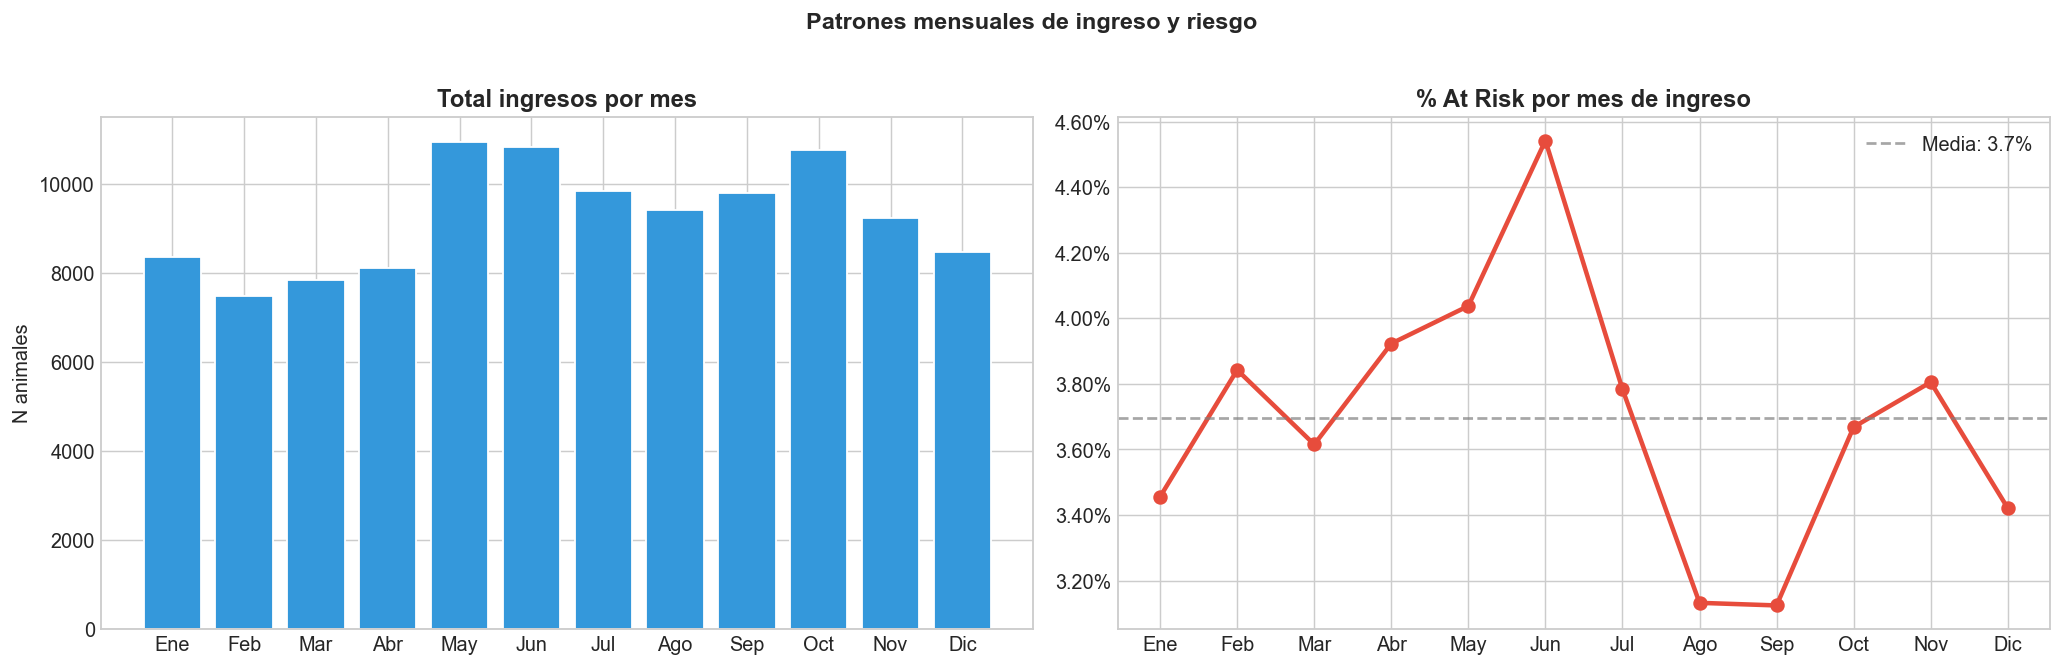

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Patrones mensuales de ingreso y riesgo",
             fontsize=13, fontweight="bold", y=1.02)

month_names = ["Ene","Feb","Mar","Abr","May","Jun",
               "Jul","Ago","Sep","Oct","Nov","Dic"]

monthly = df_pd["IntakeMonth"].value_counts().sort_index()
axes[0].bar(range(1, 13), [monthly.get(m, 0) for m in range(1, 13)],
            color="#3498db", edgecolor="white", linewidth=1)
axes[0].set_title("Total ingresos por mes", fontweight="bold")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_ylabel("N animales")

at_risk_m = df_pd.groupby("IntakeMonth").apply(
    lambda x: (x["OutcomeClass"] == "At Risk").mean() * 100)
axes[1].plot(range(1, 13), [at_risk_m.get(m, 0) for m in range(1, 13)],
             color="#e74c3c", marker="o", linewidth=2.5, markersize=7)
axes[1].set_title("% At Risk por mes de ingreso", fontweight="bold")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].axhline(at_risk_m.mean(), color="gray", linestyle="--", alpha=0.7,
                label=f"Media: {at_risk_m.mean():.1f}%")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/09_monthly_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

%% [markdown]
---
## 8. Razas en riesgo
Breed tiene mas de 2.400 valores unicos — necesita agrupacion.
Identificamos cuales tienen mayor % de At Risk
%%

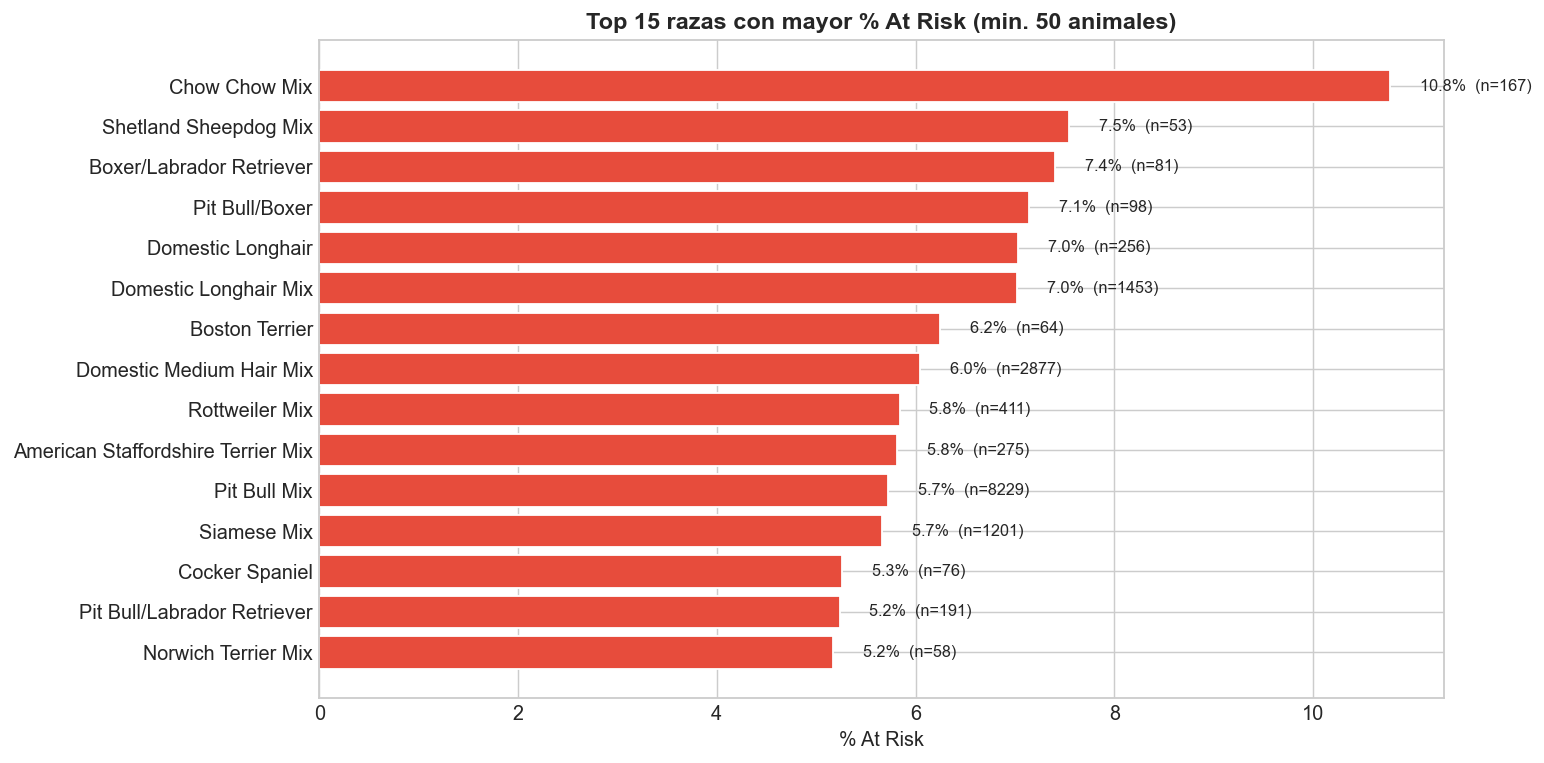

Total razas unicas: 2415
Top 10 razas mas frecuentes:
Breed
Domestic Shorthair Mix       27677
Pit Bull Mix                  8229
Labrador Retriever Mix        6699
Domestic Shorthair            6309
Chihuahua Shorthair Mix       6122
German Shepherd Mix           2953
Domestic Medium Hair Mix      2877
Australian Cattle Dog Mix     1493
Domestic Longhair Mix         1453
Pit Bull                      1257
Name: count, dtype: int64


In [14]:

breed_total  = df_pd.groupby("Breed").size().rename("total")
breed_risk_c = df_pd[df_pd["OutcomeClass"] == "At Risk"].groupby("Breed").size().rename("at_risk")
breed_df = pd.concat([breed_total, breed_risk_c], axis=1).fillna(0).astype({"at_risk": int})
breed_df["pct_at_risk"] = breed_df["at_risk"] / breed_df["total"] * 100
breed_df = breed_df[breed_df["total"] >= 50].sort_values("pct_at_risk", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(breed_df.index, breed_df["pct_at_risk"],
               color="#e74c3c", edgecolor="white", linewidth=1)
ax.set_xlabel("% At Risk")
ax.set_title("Top 15 razas con mayor % At Risk (min. 50 animales)",
             fontsize=13, fontweight="bold")
ax.invert_yaxis()
for bar, (idx, row) in zip(bars, breed_df.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{row['pct_at_risk']:.1f}%  (n={row['total']:.0f})",
            va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/10_top_breeds_at_risk.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total razas unicas: {df_pd['Breed'].nunique()}")
print("Top 10 razas mas frecuentes:")
print(df_pd["Breed"].value_counts().head(10))

%% [markdown]
---
## 9. Analisis multivariante — correlaciones

%%

C:\Users\zulay\AppData\Local\Temp\ipykernel_9764\3458793836.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_corr.select_dtypes("object").columns:


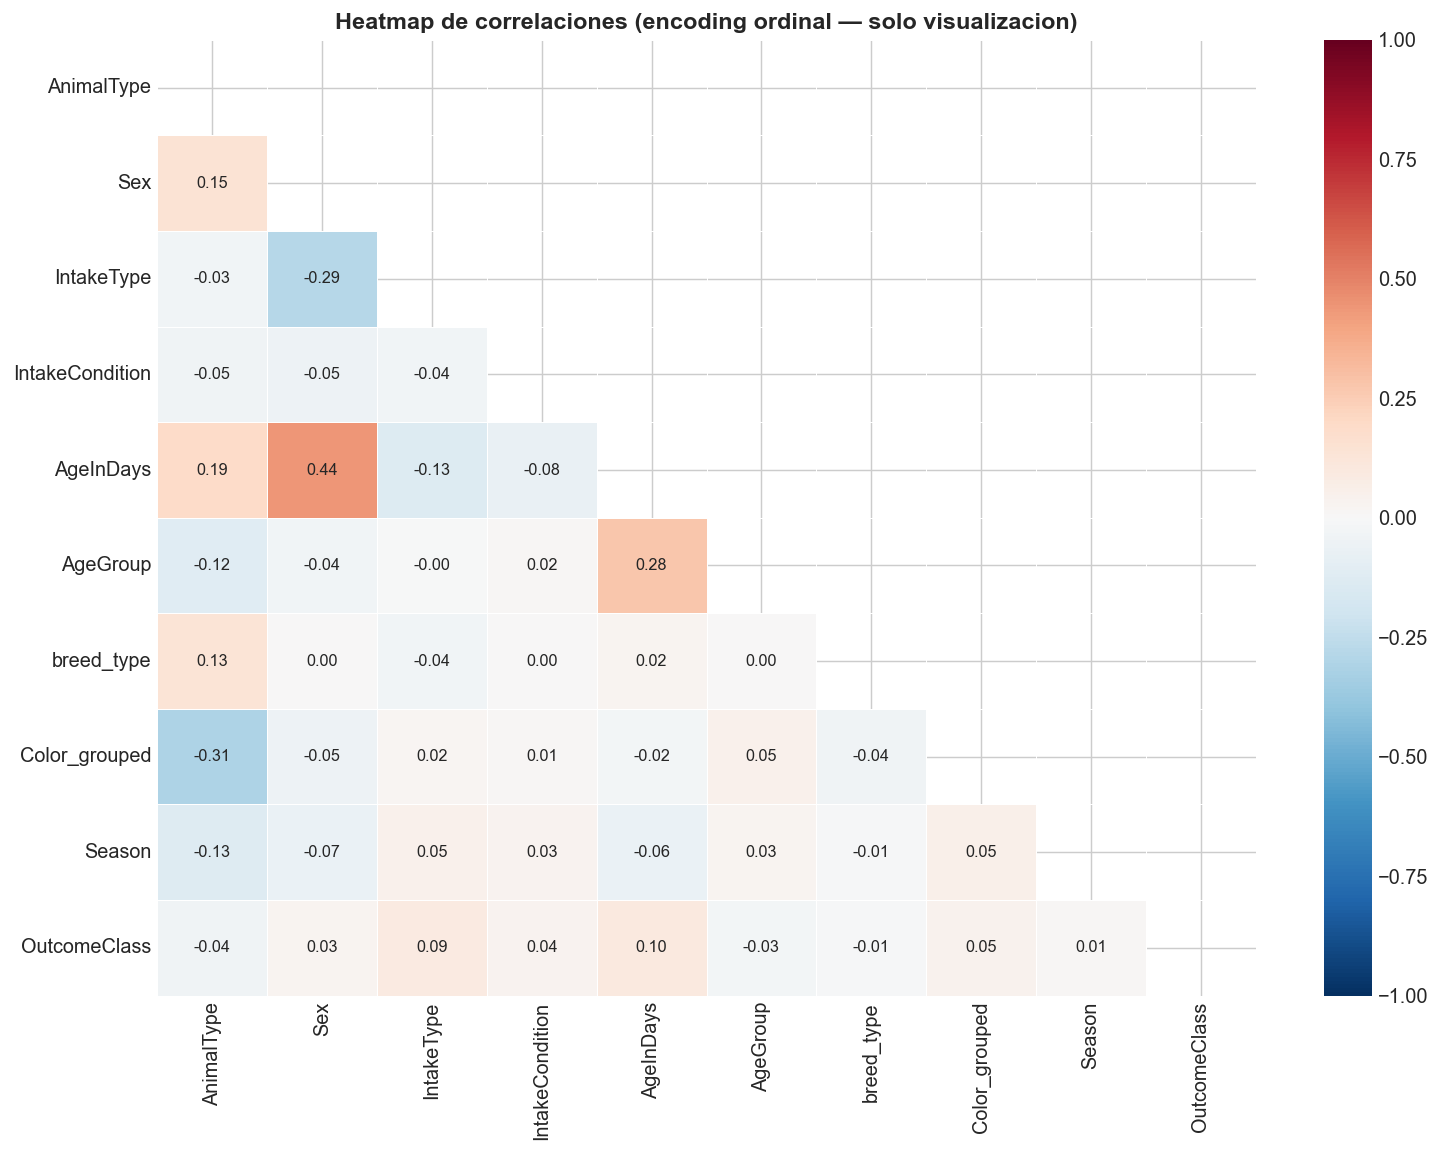

Correlacion con OutcomeClass:
  BAJA      AgeInDays              +0.0952
  BAJA      IntakeType             +0.0913
  BAJA      Color_grouped          +0.0458
  BAJA      AnimalType             -0.0434
  BAJA      IntakeCondition        +0.0383
  BAJA      Sex                    +0.0281
  BAJA      AgeGroup               -0.0267
  BAJA      Season                 +0.0105
  BAJA      breed_type             -0.0079


In [15]:

from sklearn.preprocessing import LabelEncoder

df_corr = df_pd[["AnimalType", "Sex", "IntakeType", "IntakeCondition",
                  "AgeInDays", "AgeGroup", "breed_type",
                  "Color_grouped", "Season", "OutcomeClass"]].copy()
le = LabelEncoder()
for col in df_corr.select_dtypes("object").columns:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

corr = df_corr.corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Heatmap de correlaciones (encoding ordinal — solo visualizacion)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/11_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlacion con OutcomeClass:")
corr_target = corr["OutcomeClass"].drop("OutcomeClass").sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    nivel = "ALTA    " if abs(val) > 0.3 else "MODERADA" if abs(val) > 0.1 else "BAJA    "
    print(f"  {nivel}  {feat:<22} {val:+.4f}")


AnimalType + IntakeCondition combinadas

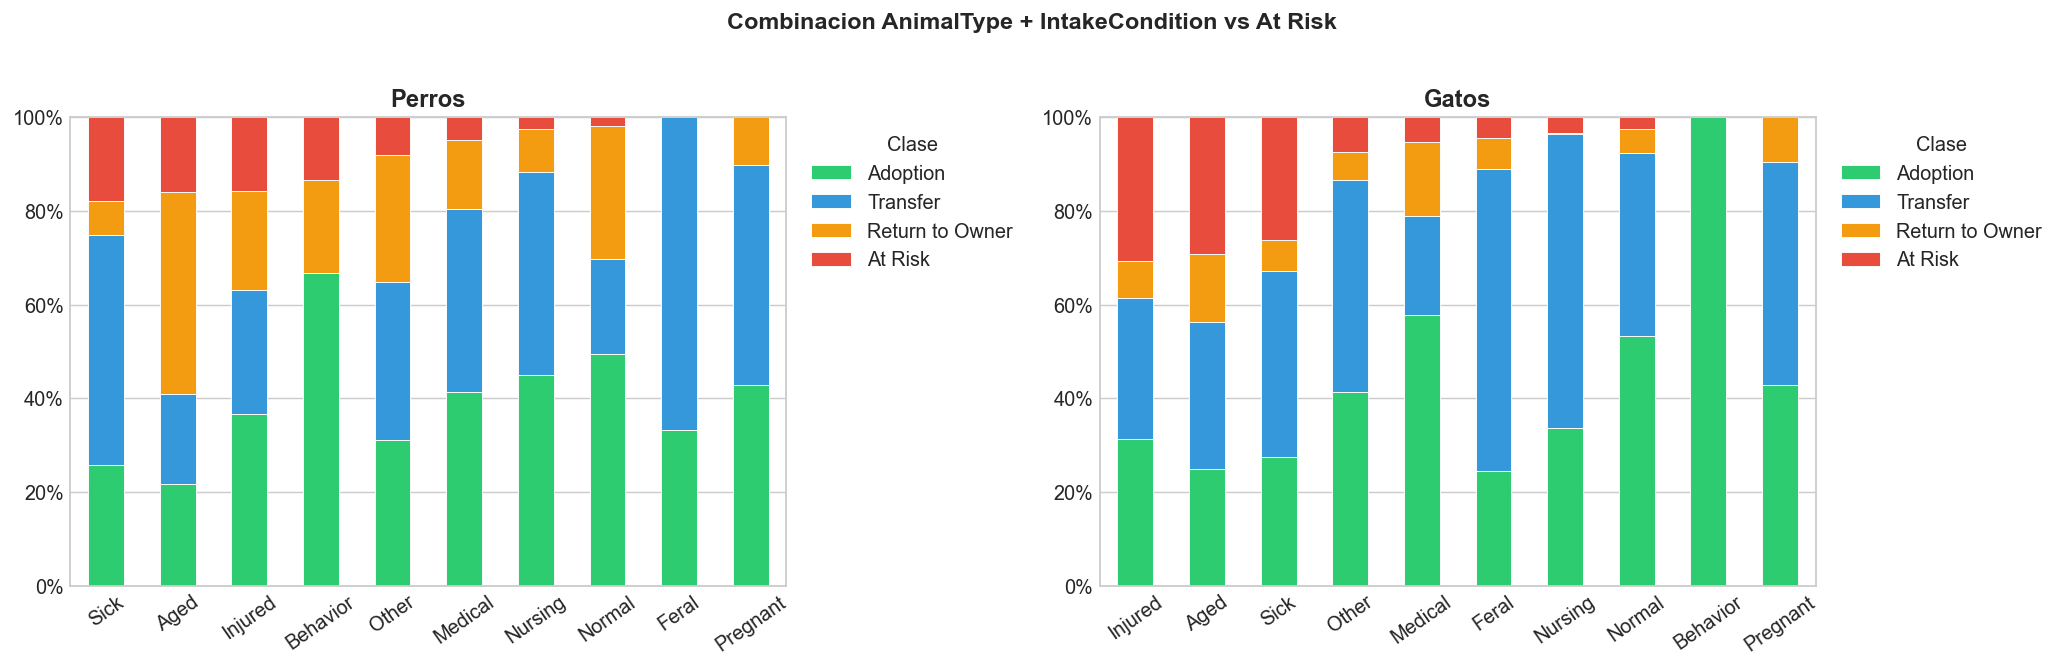

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Combinacion AnimalType + IntakeCondition vs At Risk",
             fontsize=13, fontweight="bold", y=1.02)

for ax, animal in zip(axes, ["Dog", "Cat"]):
    sub = df_pd[df_pd["AnimalType"] == animal]
    ct_c = sub.groupby(["IntakeCondition", "OutcomeClass"]).size().unstack(fill_value=0)
    ct_c = ct_c.reindex(columns=CLASS_ORDER, fill_value=0)
    pct_c = ct_c.div(ct_c.sum(axis=1), axis=0) * 100
    pct_c = pct_c.sort_values("At Risk", ascending=False)
    pct_c.plot(kind="bar", stacked=True, ax=ax,
               color=[PALETTE[c] for c in CLASS_ORDER],
               edgecolor="white", linewidth=0.5)
    ax.set_title(f"{'Perros' if animal=='Dog' else 'Gatos'}", fontweight="bold")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="Clase", bbox_to_anchor=(1.01, 1))
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("../reports/figures/12_multivariate_condition_type.png", dpi=150, bbox_inches="tight")
plt.show()

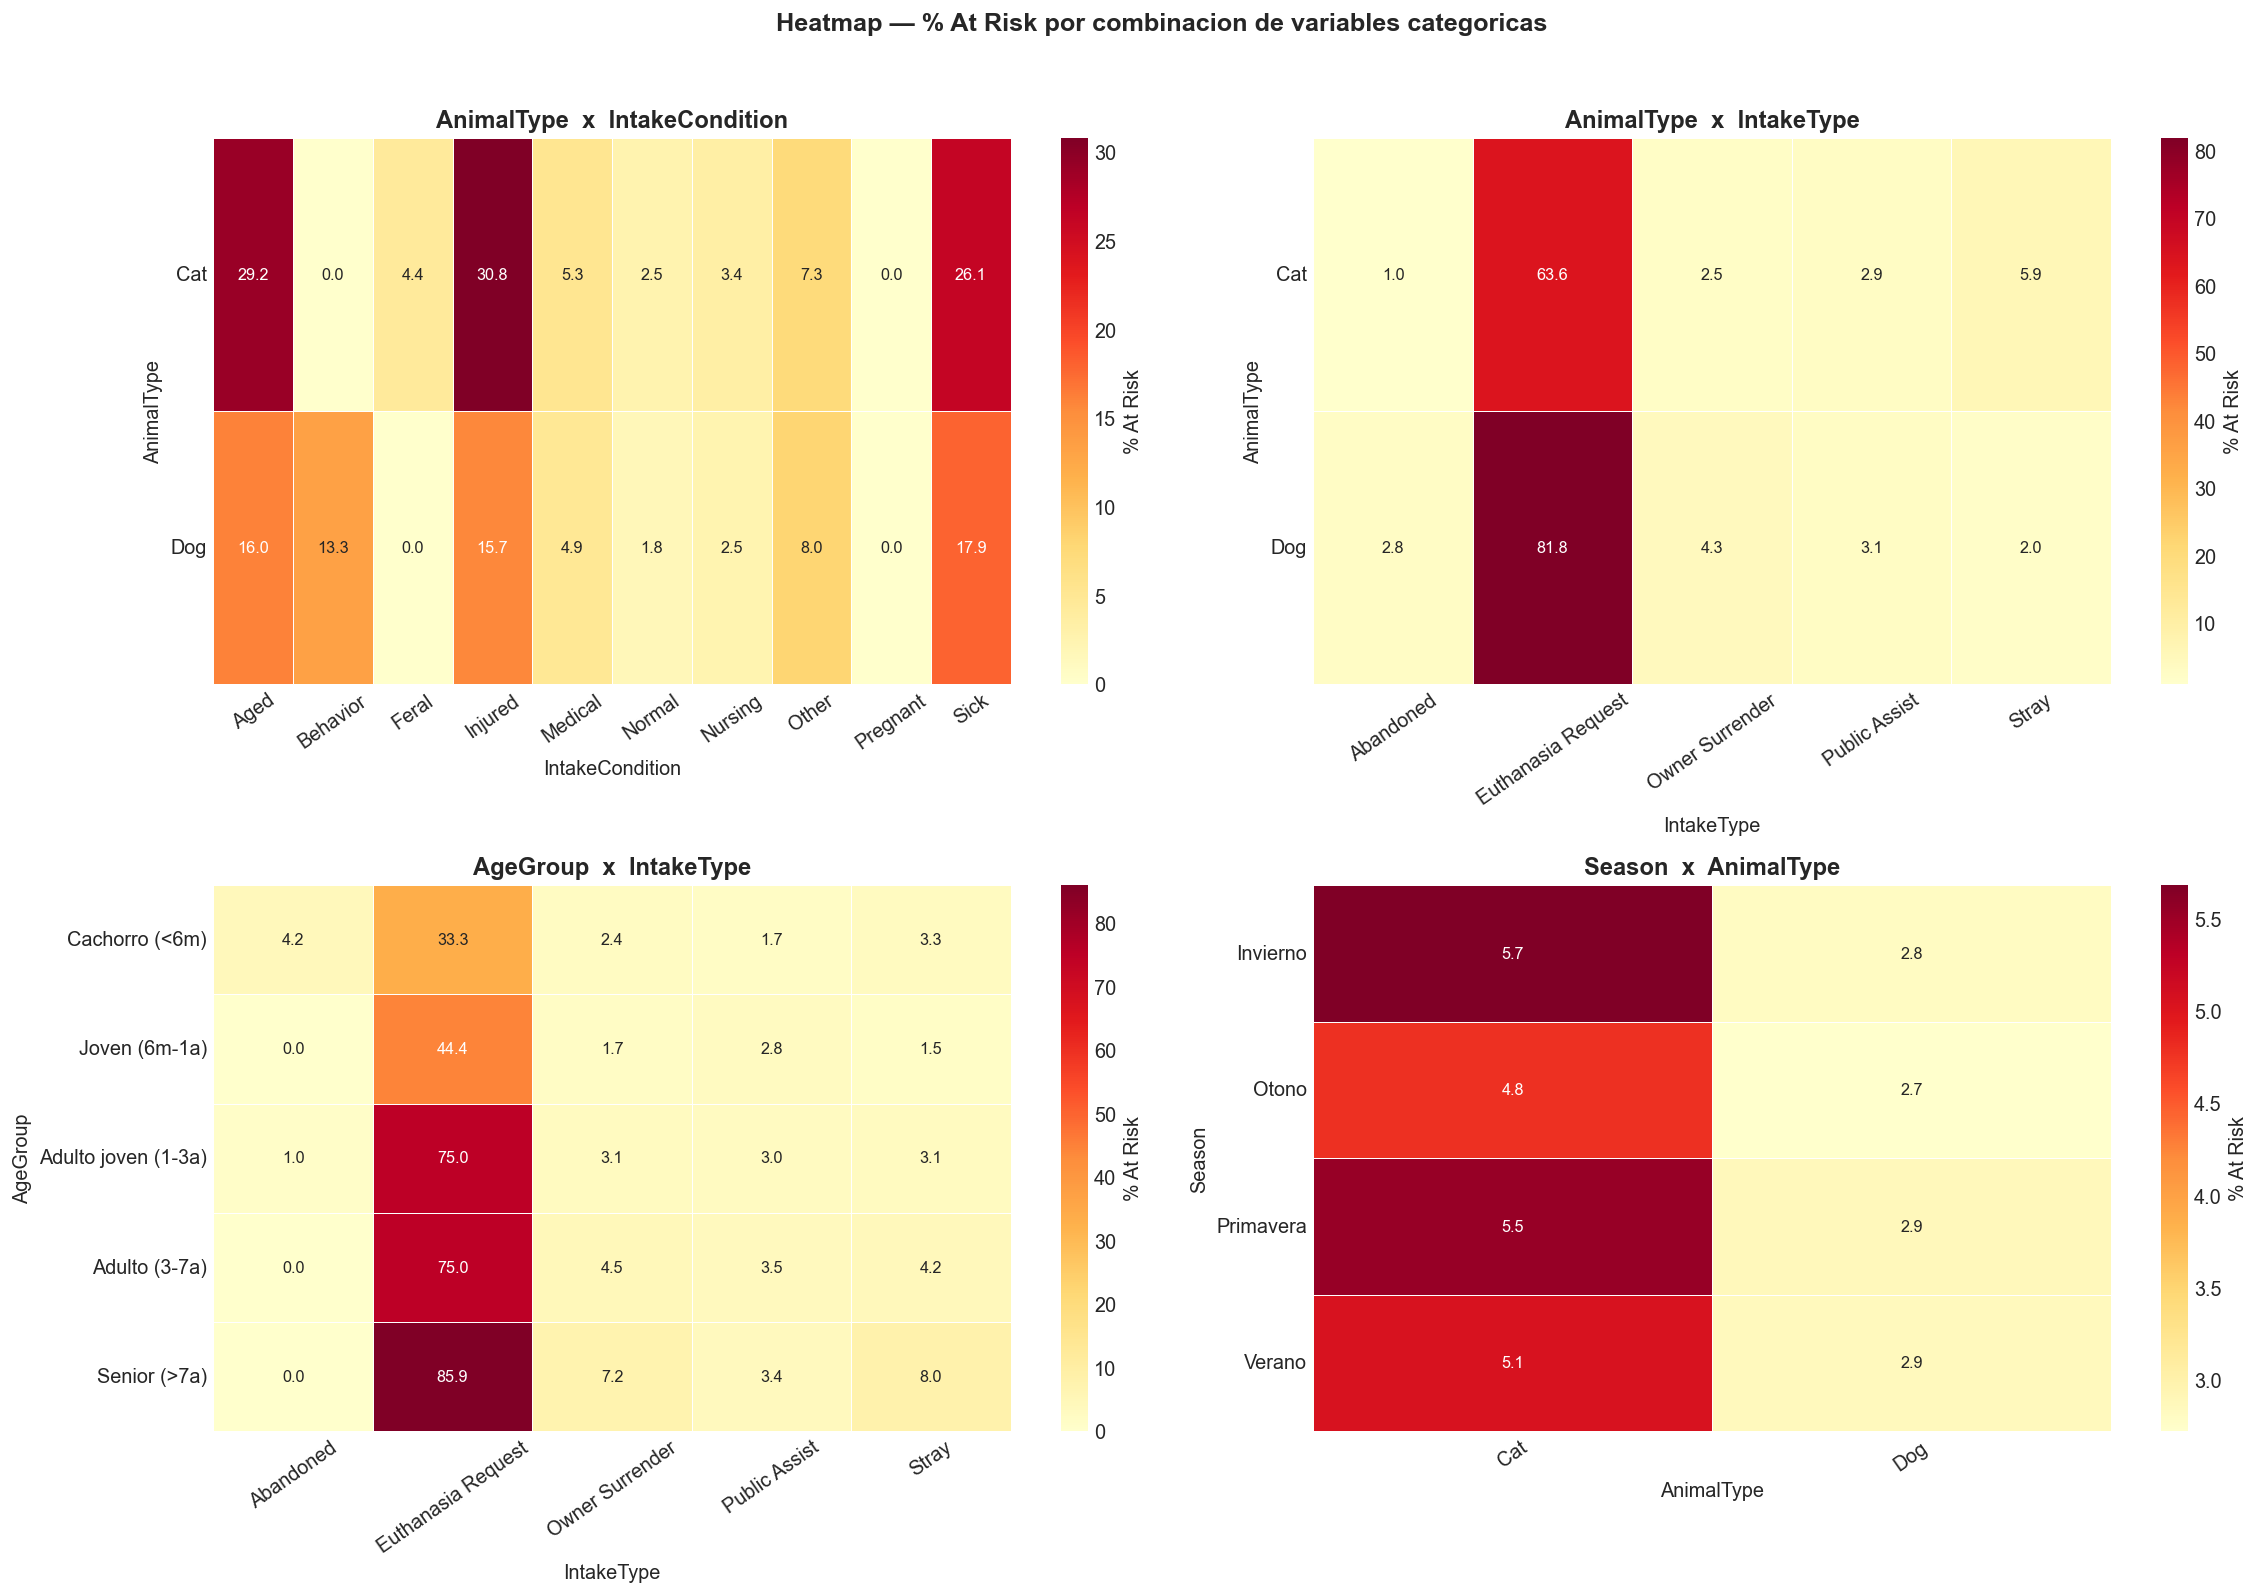

In [17]:
# ============================================
# BLOQUE 9b — HEATMAP DE CATEGÓRICAS vs At Risk
# ============================================
# Muestra el % de At Risk para cada combinación
# de dos variables categóricas — más intuitivo
# que el heatmap de correlaciones para categóricas

combos_heatmap = [
    ("AnimalType",      "IntakeCondition"),
    ("AnimalType",      "IntakeType"),
    ("AgeGroup",        "IntakeType"),
    ("Season",          "AnimalType"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Heatmap — % At Risk por combinacion de variables categoricas",
             fontsize=14, fontweight="bold", y=1.02)
axes = axes.flatten()

age_order    = ["Cachorro (<6m)", "Joven (6m-1a)", "Adulto joven (1-3a)",
                "Adulto (3-7a)", "Senior (>7a)"]
season_order = ["Primavera", "Verano", "Otono", "Invierno"]

for ax, (col1, col2) in zip(axes, combos_heatmap):
    pivot = (
        df_pd.groupby([col1, col2])["OutcomeClass"]
             .apply(lambda x: (x == "At Risk").mean() * 100)
             .unstack()
             .fillna(0)
    )

    # Reordenar si es AgeGroup o Season
    if col1 == "AgeGroup":
        pivot = pivot.reindex([a for a in age_order if a in pivot.index])
    if col2 == "AgeGroup":
        pivot = pivot.reindex(columns=[a for a in age_order if a in pivot.columns])

    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd",
                ax=ax, linewidths=0.5,
                cbar_kws={"label": "% At Risk"},
                annot_kws={"size": 9})
    ax.set_title(f"{col1}  x  {col2}", fontweight="bold")
    ax.set_xlabel(col2)
    ax.set_ylabel(col1)
    ax.tick_params(axis="x", rotation=35)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("../reports/figures/13_heatmap_categoricas_atrisk.png",
            dpi=150, bbox_inches="tight")
plt.show()

C:\Users\zulay\AppData\Local\Temp\ipykernel_9764\2995331847.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_pca.select_dtypes("object").columns:


Varianza explicada PC1: 30.4%
Varianza explicada PC2: 19.5%
Varianza total explicada: 49.9%


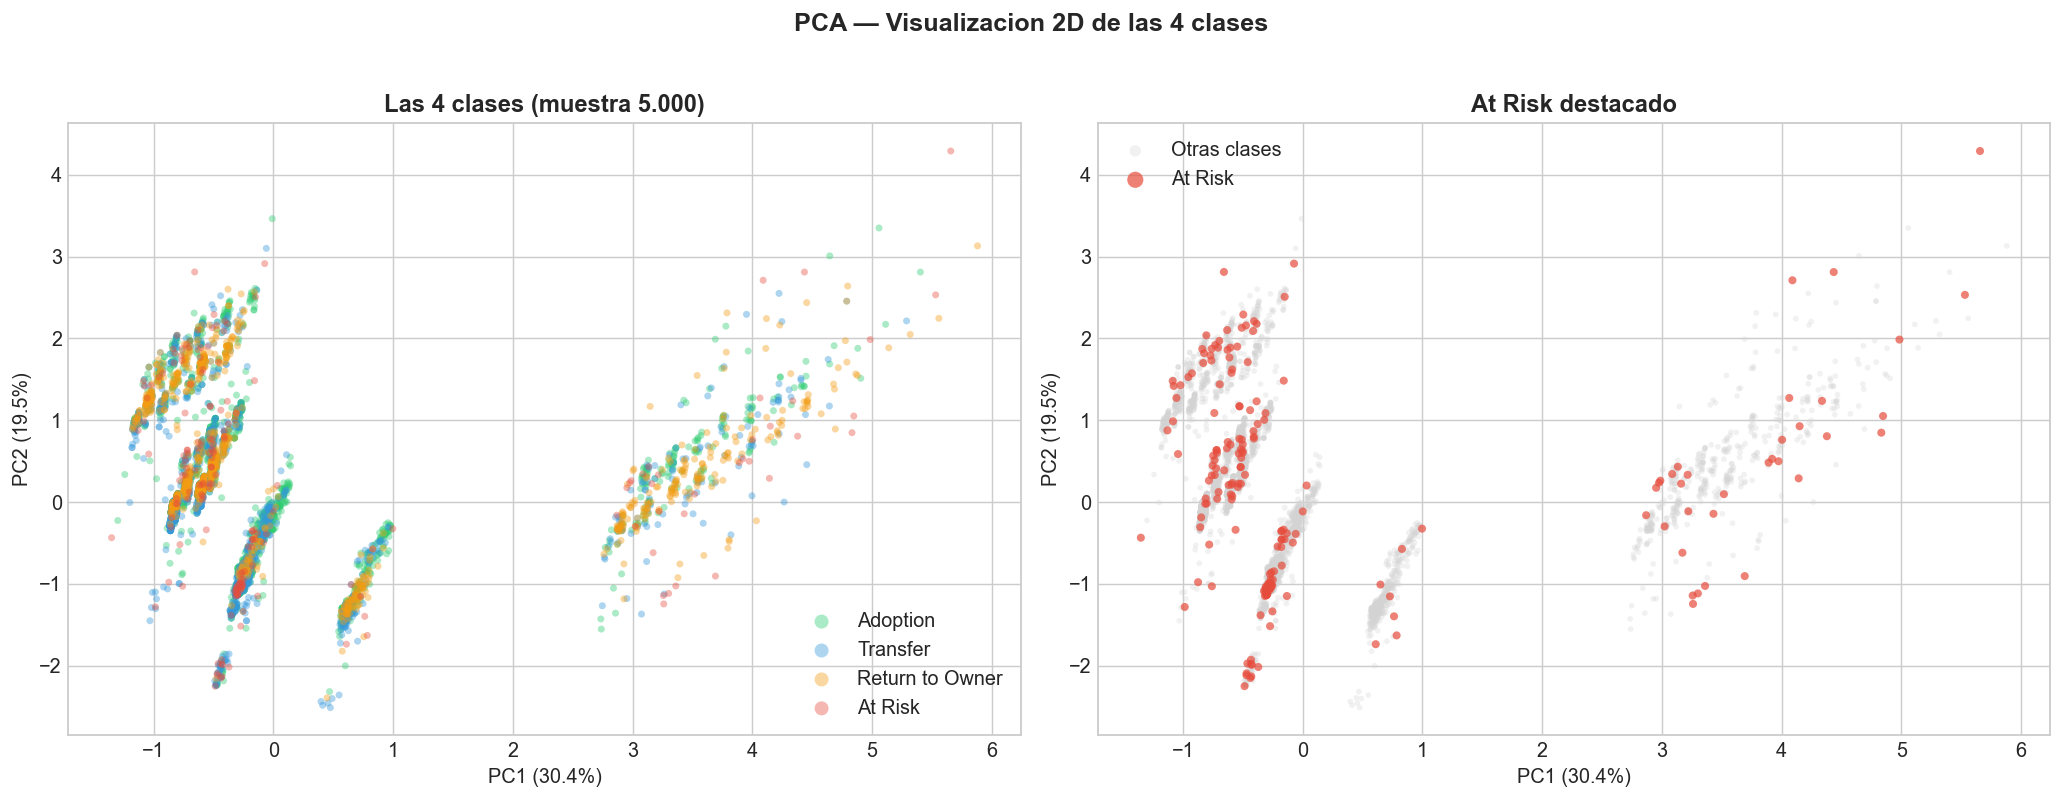


Contribucion de features al PC1 (mas influyentes):
AgeGroup           0.7629
AgeInDays          0.6276
Sex                0.1060
IntakeType        -0.1036
IntakeCondition   -0.0427
AnimalType         0.0126
Season            -0.0108
Color_grouped      0.0083
breed_type         0.0068
dtype: float64


In [18]:
# ============================================
# BLOQUE 9c — PCA (visualización 2D)
# ============================================
# El PCA reduce todas las features a 2 dimensiones
# para ver visualmente si las clases son separables.
# Si hay clusters bien definidos → el modelo lo tendrá fácil.
# Si todo se mezcla → el modelo tendrá dificultades (lo esperamos aquí).

from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler, LabelEncoder

# Preparar datos: encoding rápido solo para visualización
df_pca = df_pd[["AnimalType", "Sex", "IntakeType", "IntakeCondition",
                 "AgeInDays", "AgeGroup", "breed_type",
                 "Color_grouped", "Season", "OutcomeClass"]].copy()

le = LabelEncoder()
for col in df_pca.select_dtypes("object").columns:
    if col != "OutcomeClass":
        df_pca[col] = le.fit_transform(df_pca[col].astype(str))

# Escalar
X = df_pca.drop("OutcomeClass", axis=1).values
y = df_pca["OutcomeClass"].values
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# PCA a 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Varianza explicada PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Plot — muestra muestra para no saturar
sample_idx = np.random.choice(len(X_pca), size=5000, replace=False)
X_sample = X_pca[sample_idx]
y_sample  = y[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("PCA — Visualizacion 2D de las 4 clases",
             fontsize=14, fontweight="bold", y=1.02)

# Todas las clases juntas
for clase in CLASS_ORDER:
    mask = y_sample == clase
    axes[0].scatter(X_sample[mask, 0], X_sample[mask, 1],
                    c=PALETTE[clase], label=clase,
                    alpha=0.4, s=15, edgecolors="none")
axes[0].set_title("Las 4 clases (muestra 5.000)", fontweight="bold")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].legend(markerscale=2)

# At Risk destacado sobre el resto
mask_risk  = y_sample == "At Risk"
mask_other = y_sample != "At Risk"
axes[1].scatter(X_sample[mask_other, 0], X_sample[mask_other, 1],
                c="lightgray", alpha=0.3, s=10, label="Otras clases",
                edgecolors="none")
axes[1].scatter(X_sample[mask_risk, 0], X_sample[mask_risk, 1],
                c="#e74c3c", alpha=0.7, s=20, label="At Risk",
                edgecolors="none")
axes[1].set_title("At Risk destacado", fontweight="bold")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.savefig("../reports/figures/14_pca_2d.png", dpi=150, bbox_inches="tight")
plt.show()

# Contribucion de cada feature a los componentes
print("\nContribucion de features al PC1 (mas influyentes):")
pc1_loadings = pd.Series(
    pca.components_[0],
    index=df_pca.drop("OutcomeClass", axis=1).columns
).sort_values(key=abs, ascending=False)
print(pc1_loadings.round(4))

## 10. Conclusiones y decisiones para el modelado

In [19]:
print("=" * 65)
print("CONCLUSIONES DEL EDA")
print("=" * 65)
print("""
DATOS
  111.055 registros, 12 features, 0 nulos, 4 clases

DESBALANCE
  Adoption:        49.0%
  At Risk:          3.7%  <- critico
  Ratio 13:1 -> class_weight=balanced obligatorio
  Evaluar SMOTE si Recall At Risk < 0.55

ESCALADO
  AgeInDays: skewness > 1 -> RobustScaler preferido
  Categoricas: no requieren escalado

ENCODING
  Breed: 2.415 unicos -> agrupar top 25 + Other
  OHE:     AnimalType, Sex, IntakeType, IntakeCondition,
           breed_type, Color_grouped, Season, Breed_grouped
  Ordinal: AgeGroup (Cachorro -> Senior)
  Scaler:  AgeInDays con RobustScaler

FEATURES CON PODER DISCRIMINANTE
  1. IntakeCondition  (mayor diferencia entre clases)
  2. IntakeType
  3. AnimalType
  4. AgeGroup
  5. Breed (tras agrupacion)
  6. Season (variacion moderada)

DIVISION DE DATOS
  60% train / 20% validacion / 20% test
  StratifiedKFold k=5

METRICAS
  Principal:  F1-macro
  Critica:    Recall en At Risk (min: 0.55)
  Secundaria: Accuracy (referencia)
""")

CONCLUSIONES DEL EDA

DATOS
  111.055 registros, 12 features, 0 nulos, 4 clases

DESBALANCE
  Adoption:        49.0%
  At Risk:          3.7%  <- critico
  Ratio 13:1 -> class_weight=balanced obligatorio
  Evaluar SMOTE si Recall At Risk < 0.55

ESCALADO
  AgeInDays: skewness > 1 -> RobustScaler preferido
  Categoricas: no requieren escalado

ENCODING
  Breed: 2.415 unicos -> agrupar top 25 + Other
  OHE:     AnimalType, Sex, IntakeType, IntakeCondition,
           breed_type, Color_grouped, Season, Breed_grouped
  Ordinal: AgeGroup (Cachorro -> Senior)
  Scaler:  AgeInDays con RobustScaler

FEATURES CON PODER DISCRIMINANTE
  1. IntakeCondition  (mayor diferencia entre clases)
  2. IntakeType
  3. AnimalType
  4. AgeGroup
  5. Breed (tras agrupacion)
  6. Season (variacion moderada)

DIVISION DE DATOS
  60% train / 20% validacion / 20% test
  StratifiedKFold k=5

METRICAS
  Principal:  F1-macro
  Critica:    Recall en At Risk (min: 0.55)
  Secundaria: Accuracy (referencia)



In [20]:
df_pd.head()

,AnimalID,AnimalType,Breed,Color,Sex,IntakeType,IntakeCondition,AgeInDays,AgeGroup,breed_type,Color_grouped,Season,IntakeMonth,DaysInShelter,OutcomeClass
0,A664380,Cat,Domestic Medium Hair Mix,Calico,Intact Female,Stray,Normal,150.0,Cachorro (<6m),mix,Monocolor,Otono,10,0,Transfer
1,A650409,Dog,Australian Kelpie/Pit Bull,Black,Spayed Female,Public Assist,Normal,1095.0,Adulto (3-7a),purebred,Monocolor,Otono,10,2,Return to Owner
2,A765336,Dog,Pit Bull Mix,White/Brown Brindle,Spayed Female,Stray,Injured,365.0,Adulto joven (1-3a),mix,Bicolor,Verano,7,33,Adoption
3,A734704,Dog,Pit Bull Mix,Fawn/White,Intact Male,Stray,Normal,730.0,Adulto joven (1-3a),mix,Bicolor,Otono,9,8,Adoption
4,A683973,Cat,Russian Blue Mix,Blue,Neutered Male,Stray,Injured,1825.0,Adulto (3-7a),mix,Monocolor,Verano,7,0,At Risk


In [21]:
df_pd2 = pd.read_csv("../data/processed/animal_classification.csv")

In [22]:
df_pd2.drop(columns=["AnimalID"], inplace=True)

In [23]:
df_pd2.dropna(subset=["Sex"], inplace=True)

In [24]:
df_pd2["Sex"].unique()

<ArrowStringArray>
['Intact Female', 'Spayed Female', 'Intact Male', 'Neutered Male']
Length: 4, dtype: str

In [25]:
df_pd2['IntakeType'].unique()

<ArrowStringArray>
['Stray', 'Public Assist', 'Owner Surrender', 'Abandoned',
 'Euthanasia Request']
Length: 5, dtype: str

In [26]:
df_pd2['IntakeCondition'].unique()

<ArrowStringArray>
[  'Normal',  'Injured',     'Sick',  'Nursing',    'Feral',     'Aged',
    'Other', 'Behavior', 'Pregnant',  'Medical']
Length: 10, dtype: str

In [27]:
df_pd2 = df_pd2[df_pd2["IntakeCondition"] != "Other"]

In [28]:
df_pd2['IntakeCondition'].unique()

<ArrowStringArray>
[  'Normal',  'Injured',     'Sick',  'Nursing',    'Feral',     'Aged',
 'Behavior', 'Pregnant',  'Medical']
Length: 9, dtype: str

In [29]:
df_pd2['AnimalType'].unique()

<ArrowStringArray>
['Cat', 'Dog']
Length: 2, dtype: str

In [30]:
df_pd2.drop(columns=["Color"], inplace=True)

In [31]:
df_pd2.drop(columns=["Breed"], inplace=True)

In [32]:
df_pd2.head()

,AnimalType,Sex,IntakeType,IntakeCondition,AgeInDays,AgeGroup,breed_type,Color_grouped,Season,OutcomeClass
0,Cat,Intact Female,Stray,Normal,150.0,Cachorro (<6m),mix,Monocolor,Otoño,Transfer
1,Dog,Spayed Female,Public Assist,Normal,1095.0,Adulto (3-7a),purebred,Monocolor,Otoño,Return to Owner
2,Dog,Spayed Female,Stray,Injured,365.0,Adulto joven (1-3a),mix,Bicolor,Verano,Adoption
3,Dog,Intact Male,Stray,Normal,730.0,Adulto joven (1-3a),mix,Bicolor,Otoño,Adoption
4,Cat,Neutered Male,Stray,Injured,1825.0,Adulto (3-7a),mix,Monocolor,Verano,At Risk


In [33]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import (RobustScaler, OneHotEncoder,
                                   OrdinalEncoder, LabelEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# ── Configuración global ──
TARGET      = "OutcomeClass"
CLASS_ORDER = ["Adoption", "Transfer", "Return to Owner", "At Risk"]

FEATURES_NUM     = ["AgeInDays_log"]
FEATURES_OHE     = ["AnimalType", "Sex", "IntakeType",
                     "IntakeCondition", "breed_type",
                     "Color_grouped", "Season"]
FEATURES_ORDINAL = ["AgeGroup"]

AGE_ORDER = [["Cachorro (<6m)", "Joven (6m-1a)", "Adulto joven (1-3a)",
              "Adulto (3-7a)", "Senior (>7a)"]]

In [34]:
# ── 1. Transformación logarítmica sobre df_pd2 ──
df_pd2["AgeInDays_log"] = np.log1p(df_pd2["AgeInDays"])

print("Comparativa AgeInDays:")
print(f"  Skewness original: {df_pd2['AgeInDays'].skew():.3f}")
print(f"  Skewness log1p:    {df_pd2['AgeInDays_log'].skew():.3f}")

Comparativa AgeInDays:
  Skewness original: 2.160
  Skewness log1p:    -0.378


In [35]:
# ── 2. Label Encoding del target ──
le_target = LabelEncoder()
le_target.fit(CLASS_ORDER)

y     = df_pd2[TARGET]
y_enc = le_target.transform(y)

print("Target codificado:")
for i, c in enumerate(le_target.classes_):
    print(f"  {i} → {c}")

Target codificado:
  0 → Adoption
  1 → At Risk
  2 → Return to Owner
  3 → Transfer


In [36]:
# ── 3. Split estratificado 60/20/20 ──
X = df_pd2[FEATURES_NUM + FEATURES_OHE + FEATURES_ORDINAL]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"División estratificada 60/20/20:")
print(f"  Train:      {X_train.shape[0]:>6,} filas")
print(f"  Validación: {X_val.shape[0]:>6,} filas")
print(f"  Test:       {X_test.shape[0]:>6,} filas")

at_risk_idx = le_target.transform(["At Risk"])[0]
for nombre, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    pct = (y_split == at_risk_idx).mean() * 100
    print(f"  At Risk en {nombre}: {pct:.2f}%  ← debe ser ~3.7%")

División estratificada 60/20/20:
  Train:      66,507 filas
  Validación: 22,170 filas
  Test:       22,170 filas
  At Risk en Train: 3.70%  ← debe ser ~3.7%
  At Risk en Val: 3.70%  ← debe ser ~3.7%
  At Risk en Test: 3.70%  ← debe ser ~3.7%


In [37]:
# ── 4. Preprocesador ──
preprocessor = ColumnTransformer(
    transformers=[
        ("scaler",  RobustScaler(),  FEATURES_NUM),
        ("ohe",     OneHotEncoder(handle_unknown="ignore",
                                  sparse_output=False), FEATURES_OHE),
        ("ordinal", OrdinalEncoder(categories=AGE_ORDER,
                                   handle_unknown="use_encoded_value",
                                   unknown_value=-1), FEATURES_ORDINAL),
    ],
    remainder="drop"
)

# Fit SOLO en train
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep   = preprocessor.transform(X_val)
X_test_prep  = preprocessor.transform(X_test)

# Nombres de columnas generadas
ohe_cols = preprocessor.named_transformers_["ohe"]\
                        .get_feature_names_out(FEATURES_OHE)
all_cols = FEATURES_NUM + list(ohe_cols) + FEATURES_ORDINAL

print(f"\nShape tras preprocesado:")
print(f"  X_train: {X_train_prep.shape}")
print(f"  X_val:   {X_val_prep.shape}")
print(f"  X_test:  {X_test_prep.shape}")
print(f"\nTotal features: {len(all_cols)}")
print(f"  Numéricas:  {len(FEATURES_NUM)}")
print(f"  OHE:        {len(ohe_cols)}  → {list(ohe_cols)}")
print(f"  Ordinales:  {len(FEATURES_ORDINAL)}")


Shape tras preprocesado:
  X_train: (66507, 30)
  X_val:   (22170, 30)
  X_test:  (22170, 30)

Total features: 30
  Numéricas:  1
  OHE:        28  → ['AnimalType_Cat', 'AnimalType_Dog', 'Sex_Intact Female', 'Sex_Intact Male', 'Sex_Neutered Male', 'Sex_Spayed Female', 'IntakeType_Abandoned', 'IntakeType_Euthanasia Request', 'IntakeType_Owner Surrender', 'IntakeType_Public Assist', 'IntakeType_Stray', 'IntakeCondition_Aged', 'IntakeCondition_Behavior', 'IntakeCondition_Feral', 'IntakeCondition_Injured', 'IntakeCondition_Medical', 'IntakeCondition_Normal', 'IntakeCondition_Nursing', 'IntakeCondition_Pregnant', 'IntakeCondition_Sick', 'breed_type_mix', 'breed_type_purebred', 'Color_grouped_Bicolor', 'Color_grouped_Monocolor', 'Season_Invierno', 'Season_Otoño', 'Season_Primavera', 'Season_Verano']
  Ordinales:  1


In [38]:
# ── 4b. SMOTE sobre X_train_prep ──
# Solo sobre train — val y test nunca se tocan
# X_train_prep ya está procesado (numérico) → SMOTE puede trabajar

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)

print("Distribución ANTES de SMOTE (train):")
for idx, clase in enumerate(le_target.classes_):
    n = (y_train == idx).sum()
    print(f"  {clase:<22} {n:>5,}")

print("\nDistribución DESPUÉS de SMOTE (train):")
for idx, clase in enumerate(le_target.classes_):
    n = (y_train_bal == idx).sum()
    print(f"  {clase:<22} {n:>5,}")

print(f"\nTrain original:   {X_train_prep.shape[0]:,} filas")
print(f"Train balanceado: {X_train_bal.shape[0]:,} filas")
print(f"\n⚠️  Val y Test NO se tocan — representan la realidad")

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
# Guardar df_pd2 como CSV listo para modelado
df_pd2.to_csv("../data/processed/animal_ready_for_modeling.csv", index=False)

print("✅ Dataset listo para modelado guardado:")
print(f"   Ruta: ../data/processed/animal_ready_for_modeling.csv")
print(f"   Shape: {df_pd2.shape}")
print(f"   Columnas: {df_pd2.columns.tolist()}")
print(f"\n   Features numéricos: {FEATURES_NUM}")
print(f"   Features OHE: {FEATURES_OHE}")
print(f"   Features ordinales: {FEATURES_ORDINAL}")
print(f"   Target: {TARGET}")

✅ Dataset listo para modelado guardado:
   Ruta: ../data/processed/animal_ready_for_modeling.csv
   Shape: (110847, 11)
   Columnas: ['AnimalType', 'Sex', 'IntakeType', 'IntakeCondition', 'AgeInDays', 'AgeGroup', 'breed_type', 'Color_grouped', 'Season', 'OutcomeClass', 'AgeInDays_log']

   Features numéricos: ['AgeInDays_log']
   Features OHE: ['AnimalType', 'Sex', 'IntakeType', 'IntakeCondition', 'breed_type', 'Color_grouped', 'Season']
   Features ordinales: ['AgeGroup']
   Target: OutcomeClass
